# Combined Filter

Loads processed outputs from `mems_filter.ipynb` and `spec_filter.ipynb` and merges them into one DataFrame per sub-dataset.

**Run both source notebooks first** (execute their export cells) before running this notebook.

Each sub-dataset combines:
- **MEMS channels**: VOC, NH3, HCHO (drift-corrected, EMA-filtered)
- **SPEC channels**: H2S ppm, EtOH ppm (offset-corrected, two-stage filtered)
- **ENV channels**: temp_C, rh_pct

In [155]:
import os
import matplotlib.pyplot as plt
import pandas as pd

PROCESSED = "processed"

MEMS = ["voc", "nh3", "hcho"]
SPEC = ["h2s_ppm", "etoh_ppm"]
ENV  = ["temp_C", "rh_pct"]
ALL_CHANNELS = MEMS + SPEC + ENV

# ── Auto-discover and load all processed pickles ──────────────────────────────
def _load_pickles(prefix):
    result = {}
    for fname in sorted(os.listdir(PROCESSED)):
        if fname.startswith(prefix) and fname.endswith(".pkl"):
            key = fname[len(prefix):-4]   # strip prefix and .pkl extension
            result[key] = pd.read_pickle(os.path.join(PROCESSED, fname))
    return result

mems = _load_pickles("mems_")
spec = _load_pickles("spec_")

print(f"MEMS pickles loaded ({len(mems)}):")
for k, df in mems.items():
    print(f"  {k:<12}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")

print(f"\nSPEC pickles loaded ({len(spec)}):")
for k, df in spec.items():
    print(f"  {k:<12}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")

mems_only = set(mems) - set(spec)
spec_only = set(spec) - set(mems)
if mems_only:
    print(f"\nWARNING: in MEMS but missing SPEC pickle: {sorted(mems_only)}")
if spec_only:
    print(f"\nWARNING: in SPEC but missing MEMS pickle: {sorted(spec_only)}")

MEMS pickles loaded (18):
  blood_0        3666 rows  elapsed 0–3753 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_1        1908 rows  elapsed 1751–3703 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_2        2882 rows  elapsed 0–2987 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_3        3324 rows  elapsed 0–3484 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_4        2357 rows  elapsed 0–2473 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_5        3598 rows  elapsed 0–3746 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_6        3383 rows  elapsed 500–3963 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_7        3486 rows  elapsed 0–3568 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_8        3216 rows  elapsed 501–3791 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_p

## Merge

MEMS and SPEC data come from the same CSV recorded at 1 Hz, so `elapsed_s` should align exactly. The merge checks this explicitly:

1. **Exact match** — merge on `elapsed_s` directly; if every row matches, use as-is.
2. **Nearest-match fallback** — if any rows are unmatched (floating-point drift or minor resampling difference), `merge_asof` within `MERGE_TOL` seconds is used instead. Rows outside the tolerance are dropped and reported.

Each merged dataset gets a `session` column (e.g. `"sweat_2"`) so that downstream train/validate/test splits can group by session.

In [156]:
MERGE_TOL = 0.5  # seconds — tolerance for nearest-match fallback

datasets = {}

print(f"{'Dataset':<12}  {'MEMS':>6}  {'SPEC':>6}  {'Merged':>7}  {'Dropped':>8}  {'Method'}")
print("-" * 58)

for key in sorted(mems):
    if key not in spec:
        print(f"{key:<12}  -- no SPEC pickle, skipped --")
        continue

    m = mems[key]
    s = spec[key]

    # Exact merge on elapsed_s
    exact = pd.merge(
        m,
        s[["elapsed_s"] + SPEC],
        on="elapsed_s",
        how="inner",
    )
    n_exact_dropped = max(len(m), len(s)) - len(exact)

    if n_exact_dropped == 0:
        merged = exact
        method = "exact"
    else:
        # Nearest-match fallback — sorts required by merge_asof
        m_s = m.sort_values("elapsed_s").reset_index(drop=True)
        s_s = s[["elapsed_s"] + SPEC].sort_values("elapsed_s").reset_index(drop=True)
        merged = pd.merge_asof(
            m_s, s_s,
            on="elapsed_s",
            tolerance=MERGE_TOL,
            direction="nearest",
        )
        merged = merged.dropna(subset=SPEC).reset_index(drop=True)
        method = f"nearest (tol={MERGE_TOL}s)"

    n_dropped = max(len(m), len(s)) - len(merged)
    flag = "  *** ROWS DROPPED ***" if n_dropped > 0 else ""

    merged = merged[["elapsed_s"] + ALL_CHANNELS].reset_index(drop=True)
    merged["session"] = key
    datasets[key] = merged

    print(f"{key:<12}  {len(m):>6}  {len(s):>6}  {len(merged):>7}  {n_dropped:>8}  {method}{flag}")

print(f"\nTotal sessions merged: {len(datasets)}")

Dataset         MEMS    SPEC   Merged   Dropped  Method
----------------------------------------------------------
blood_0         3666    3666     3666         0  exact
blood_1         1908    1908     1908         0  exact
blood_2         2882    2882     2882         0  exact
blood_3         3324    3324     3324         0  exact
blood_4         2357    2357     2357         0  exact
blood_5         3598    3598     3598         0  exact
blood_6         3383    3383     3383         0  exact
blood_7         3486    3486     3486         0  exact
blood_8         3216    3216     3216         0  exact
blood_9         4093    4093     4093         0  exact
sweat_1a        3909    3909     3909         0  exact
sweat_1b        2390    2390     2390         0  exact
sweat_2         5393    5393     5393         0  exact
sweat_3         5106    5106     5106         0  exact
sweat_4         4930    4930     4930         0  exact
sweat_5         2723    2723     2723         0  exact
sweat

In [157]:
# ── Hold out unseen test sessions — must happen BEFORE feature engineering ────
# sweat_7 : most recent sweat session (20260429), clean data, no zero channels
# blood_9 : later blood session (20260426), clean data, typical channel ranges
TEST_SESSIONS = {"sweat_7", "blood_9"}

test_datasets = {k: datasets.pop(k) for k in TEST_SESSIONS}

print(f"Training sessions ({len(datasets)}): {sorted(datasets)}")
print(f"Test sessions     ({len(test_datasets)}): {sorted(test_datasets)}")


Training sessions (16): ['blood_0', 'blood_1', 'blood_2', 'blood_3', 'blood_4', 'blood_5', 'blood_6', 'blood_7', 'blood_8', 'sweat_1a', 'sweat_1b', 'sweat_2', 'sweat_3', 'sweat_4', 'sweat_5', 'sweat_6']
Test sessions     (2): ['blood_9', 'sweat_7']


## Channel Verification

In [158]:
for key, df in datasets.items():
    print(f"\n{key}")
    print(f"  {'Channel':<12} {'min':>10} {'max':>10} {'nulls':>8}")
    print(f"  {'-'*44}")
    for col in ALL_CHANNELS:
        null_count = df[col].isna().sum()
        print(f"  {col:<12} {df[col].min():>10.4f} {df[col].max():>10.4f} {null_count:>8}")



blood_0
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.4240        0
  nh3              0.0000     0.1873        0
  hcho             0.0000     0.4612        0
  h2s_ppm          0.0000     0.1261        0
  etoh_ppm         0.0000     3.2131        0
  temp_C          20.5000    21.7000        0
  rh_pct          26.7000    50.1000        0

blood_1
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.2372        0
  nh3              0.0000     0.2181        0
  hcho             0.0000     0.4332        0
  h2s_ppm          0.0000     0.1543        0
  etoh_ppm         0.0000     3.4523        0
  temp_C          20.2000    20.4000        0
  rh_pct          30.6000    46.9000        0

blood_2
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.1875        0
  nh

## Data Labelling

Each row is assigned one of three labels based on whether a sample was physically present in the sensor chamber:

| Label | Value | Meaning |
|-------|-------|---------|
| `baseline` | 0 | No sample — sensor warming up or idle |
| `sweat`    | 1 | Sweat sample in chamber |
| `blood`    | 2 | Blood sample in chamber |

Windows are defined in `SAMPLE_WINDOWS` below as `(t_start, t_end, label)` and run from the sample introduction event to the end of the session. All rows outside any window default to `baseline`. Adjust boundaries after reviewing the plots.

In [159]:
LABEL_BASELINE = 0
LABEL_SWEAT    = 1
LABEL_BLOOD    = 2

# (t_start, t_end, label) — t_end=None means end of session
SAMPLE_WINDOWS = {
    "sweat_1a": [(2870, 3860, LABEL_SWEAT)],
    "sweat_1b": [(570 , 2330, LABEL_SWEAT)],
    "sweat_2":  [(4220, 5460, LABEL_SWEAT)],
    "sweat_3":  [(3550, 5227, LABEL_SWEAT)],
    "sweat_4":  [(3860, 5042, LABEL_SWEAT)],
    "sweat_5":  [(1140, 2786, LABEL_SWEAT)],
    "sweat_6":  [(4600, 6120, LABEL_SWEAT)],
    "sweat_7":  [(1750, 3610, LABEL_SWEAT)],
    "blood_0":  [(1900, 3730, LABEL_BLOOD)],
    "blood_1":  [(2440, 3703, LABEL_BLOOD)],
    "blood_2":  [(1770, 2987, LABEL_BLOOD)],
    "blood_3":  [(1950, 3484, LABEL_BLOOD)],
    "blood_4":  [(1360, 2440, LABEL_BLOOD)],
    "blood_5":  [(1750, 3746, LABEL_BLOOD)],
    "blood_6":  [(2650, 3950, LABEL_BLOOD)],
    "blood_7":  [(2150, 3568, LABEL_BLOOD)],
    "blood_8":  [(2430, 3791, LABEL_BLOOD)],
    "blood_9":  [(2290, 4190, LABEL_BLOOD)],
}

for key, df in datasets.items():
    datasets[key] = df.copy()
    datasets[key]["label"] = LABEL_BASELINE
    for t_start, t_end, lbl in SAMPLE_WINDOWS.get(key, []):
        t = df["elapsed_s"]
        mask = (t >= t_start) & (t <= t_end)
        datasets[key].loc[mask, "label"] = lbl

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Dataset':<12}  {'baseline':>10}  {'sweat':>8}  {'blood':>8}  {'total':>8}  {'sample %':>9}")
print("-" * 64)
for key, df in sorted(datasets.items()):
    b  = (df["label"] == LABEL_BASELINE).sum()
    sw = (df["label"] == LABEL_SWEAT).sum()
    bl = (df["label"] == LABEL_BLOOD).sum()
    sample_pct = 100 * (sw + bl) / len(df)
    print(f"{key:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(df):>8}  {sample_pct:>8.1f}%")

Dataset         baseline     sweat     blood     total   sample %
----------------------------------------------------------------
blood_0             1879         0      1787      3666      48.7%
blood_1              675         0      1233      1908      64.6%
blood_2             1717         0      1165      2882      40.4%
blood_3             1860         0      1464      3324      44.0%
blood_4             1325         0      1032      2357      43.8%
blood_5             1690         0      1908      3598      53.0%
blood_6             2113         0      1270      3383      37.5%
blood_7             2101         0      1385      3486      39.7%
blood_8             1887         0      1329      3216      41.3%
sweat_1a            2942       967         0      3909      24.7%
sweat_1b             671      1719         0      2390      71.9%
sweat_2             4182      1211         0      5393      22.5%
sweat_3             3468      1638         0      5106      32.1%
sweat_4    

### Label Visualization

Shaded regions show the labelled time windows — **grey** = baseline, **green** = sweat, **red** = blood.

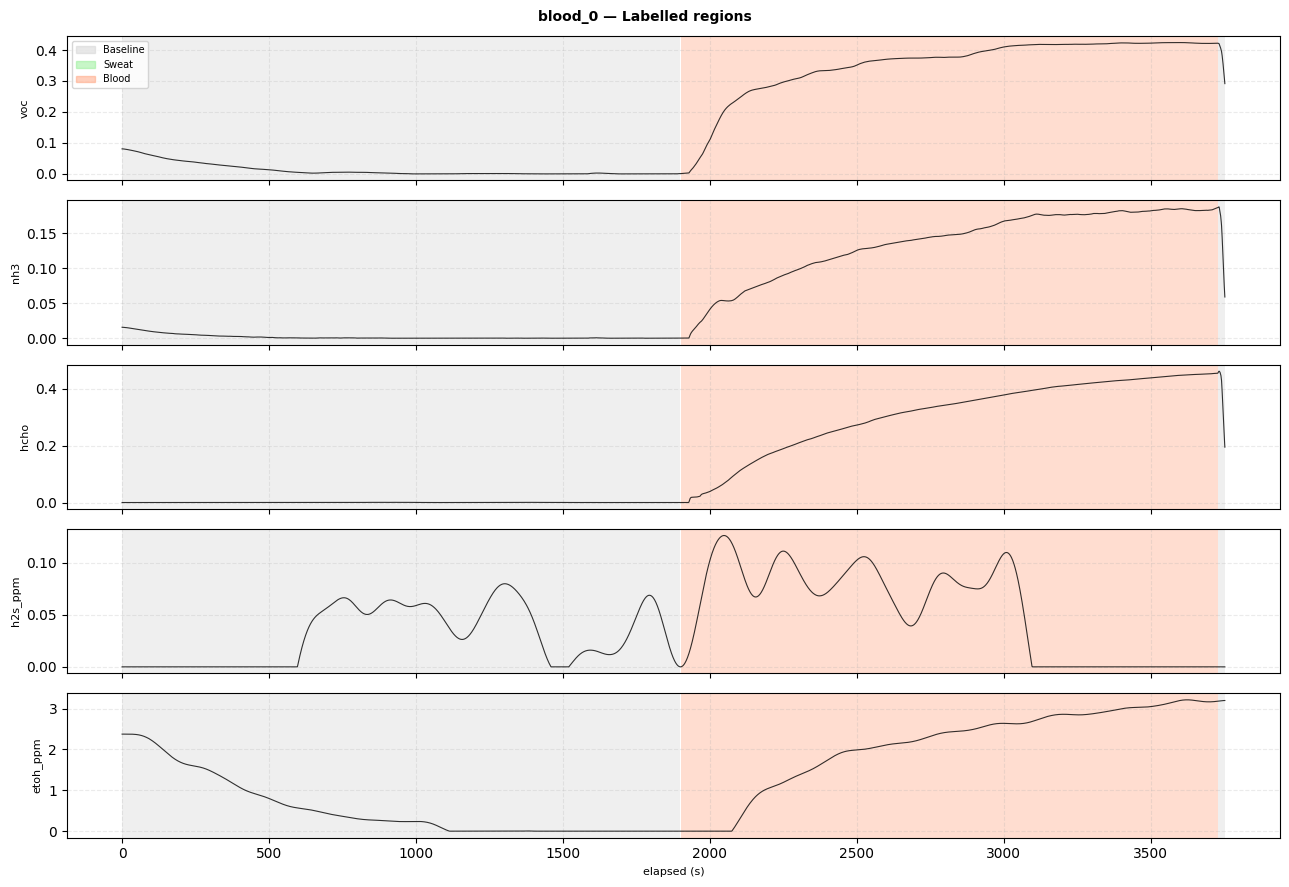

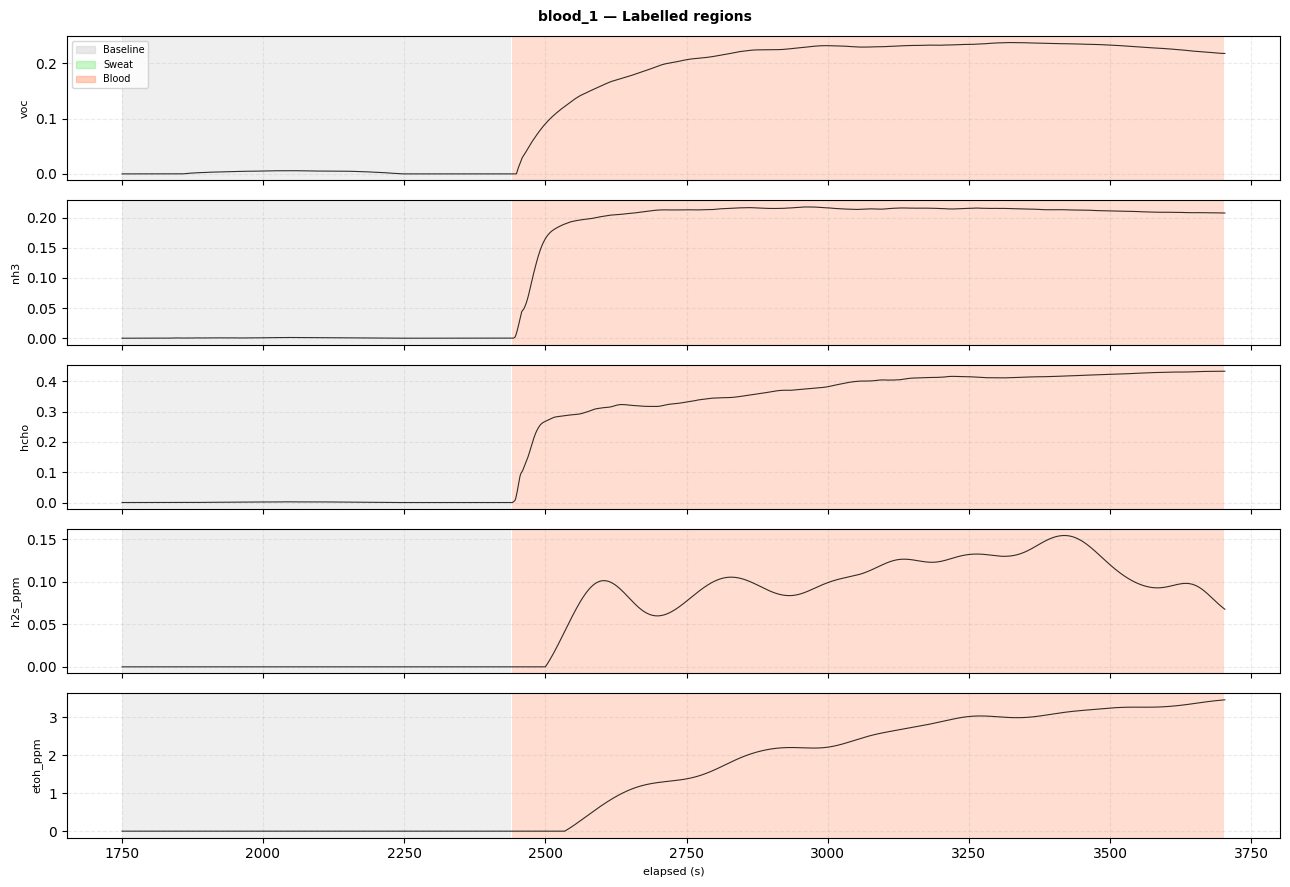

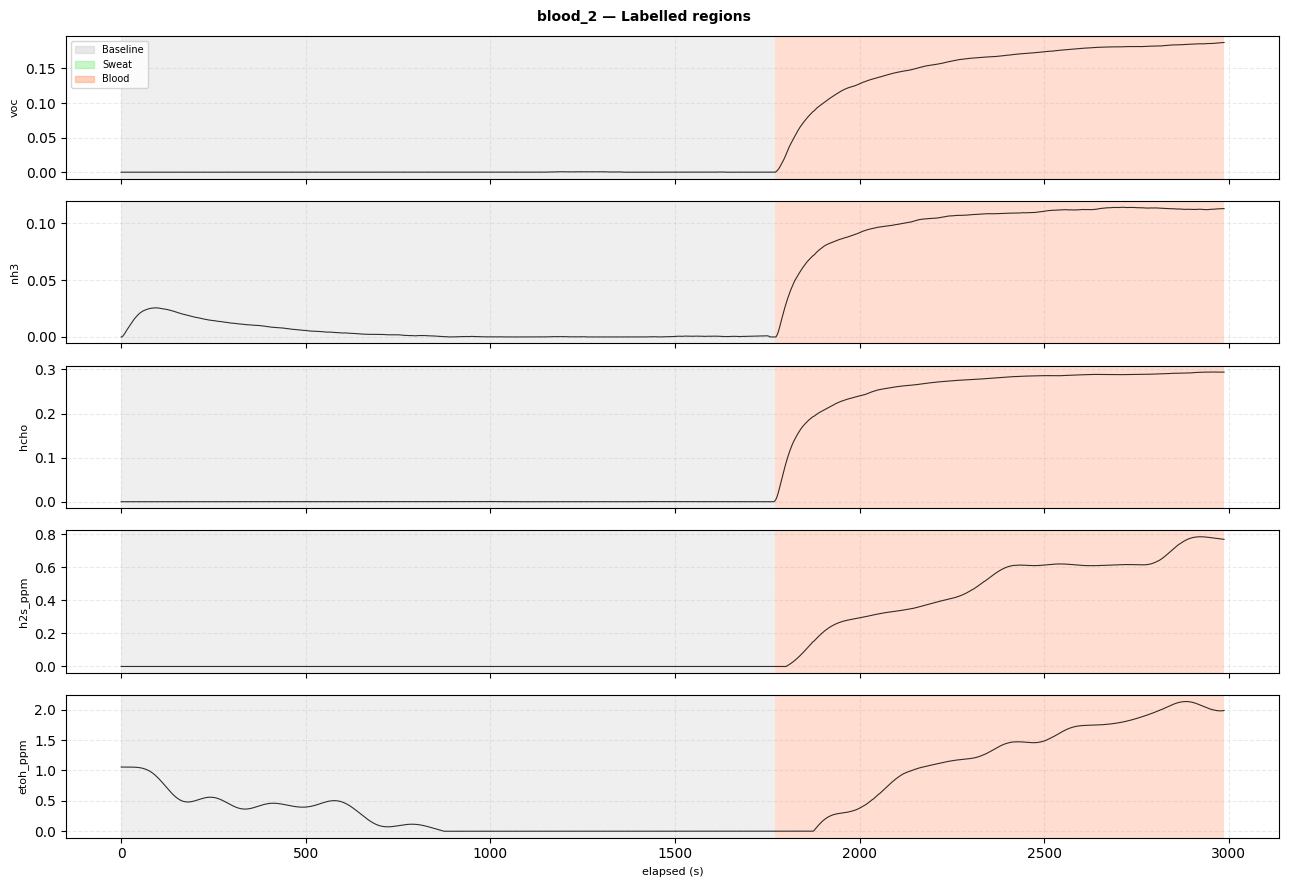

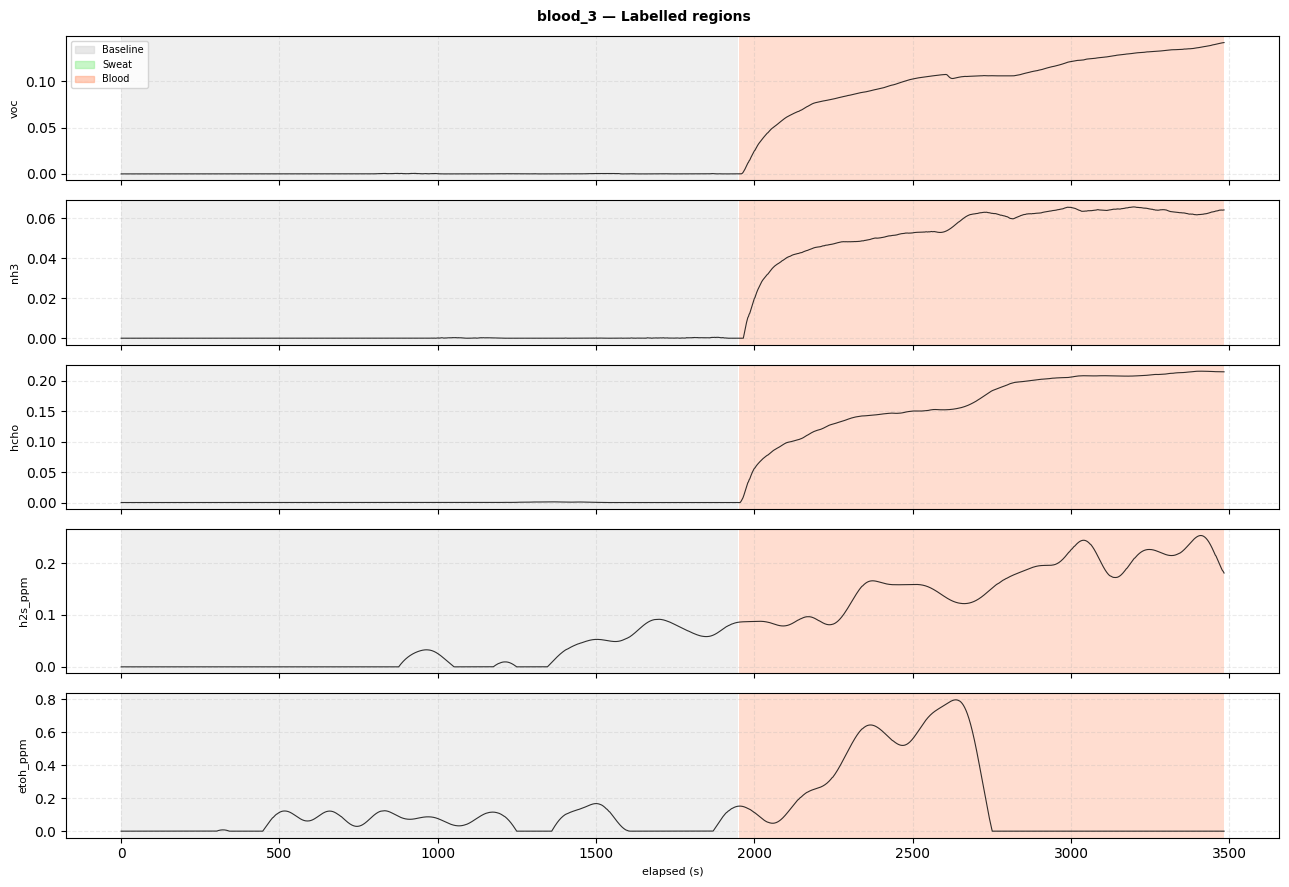

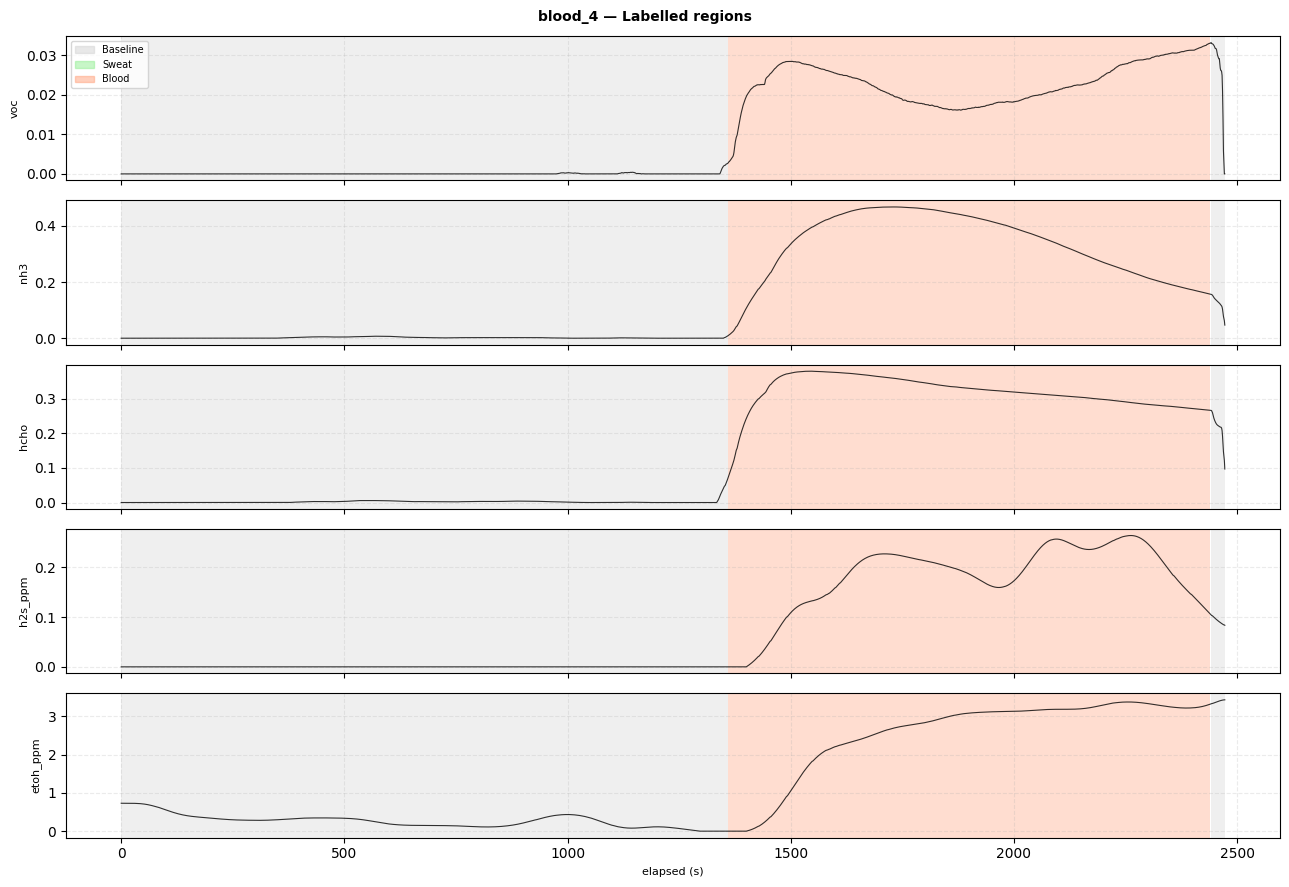

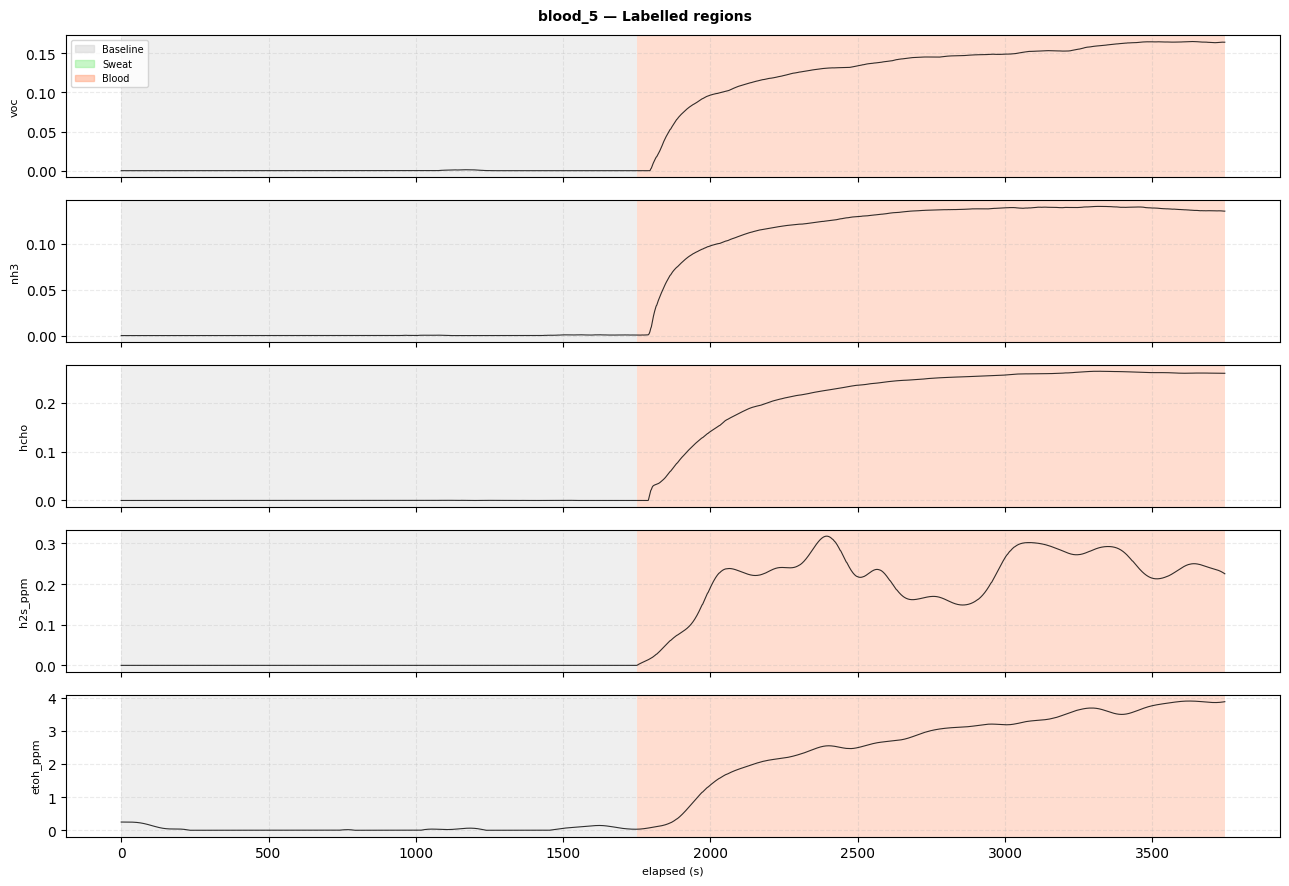

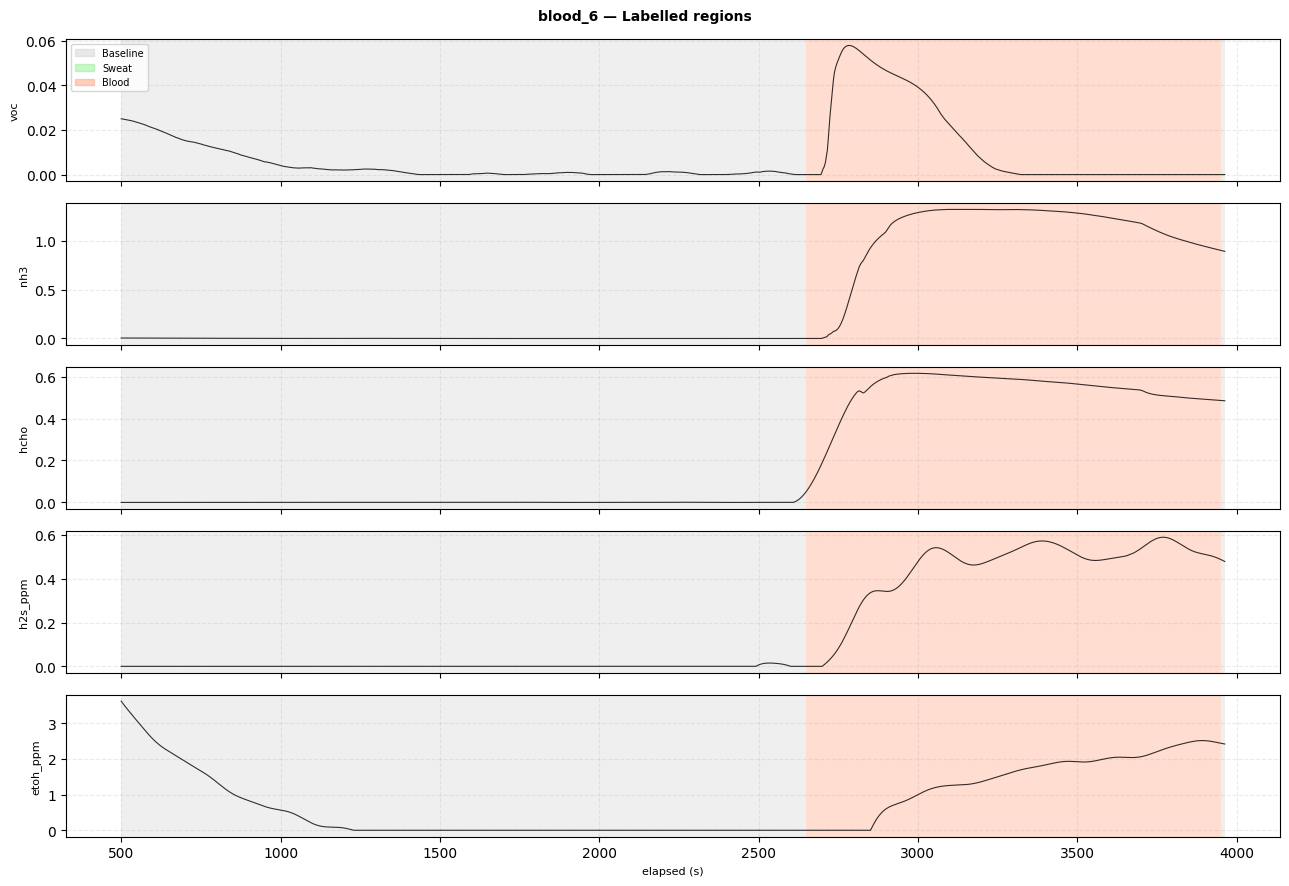

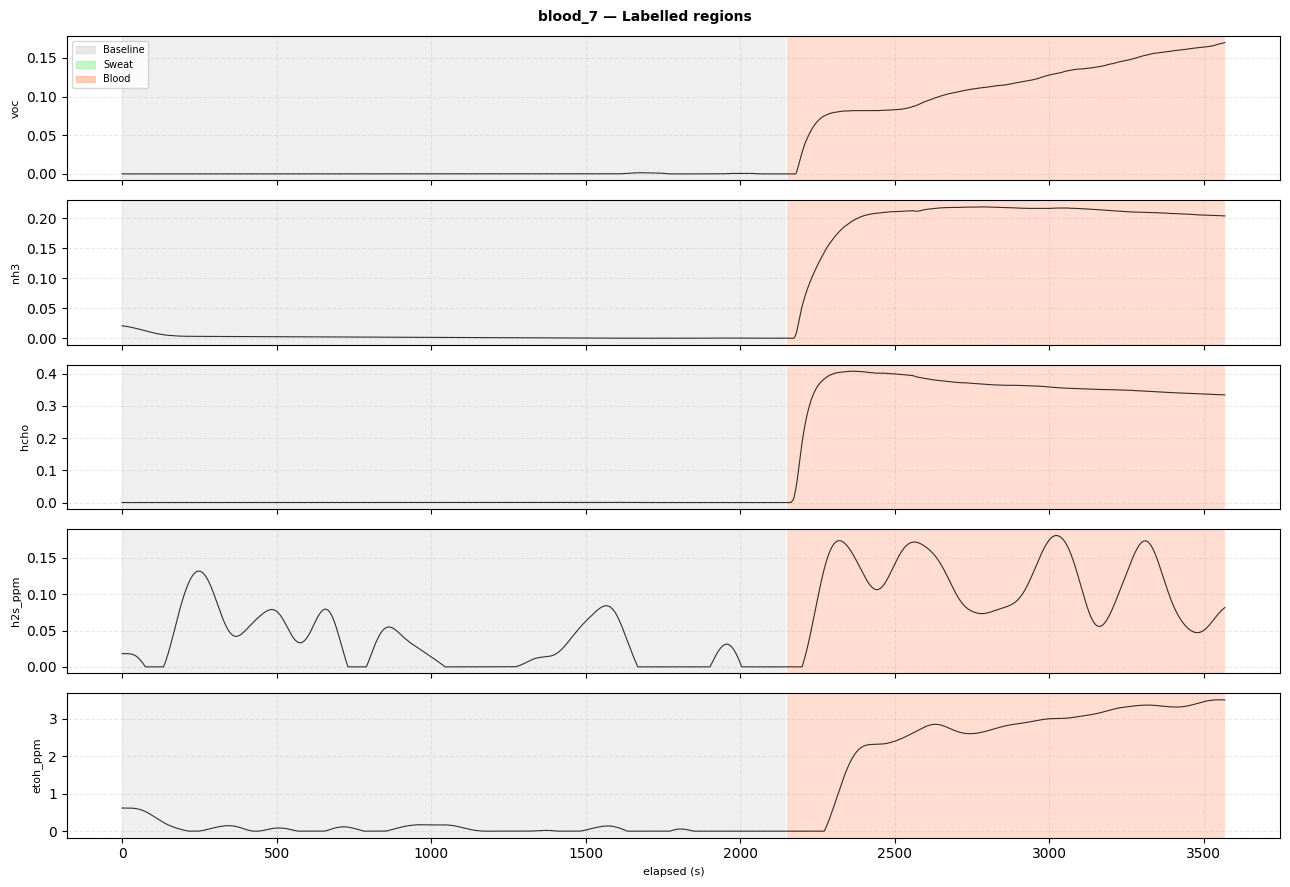

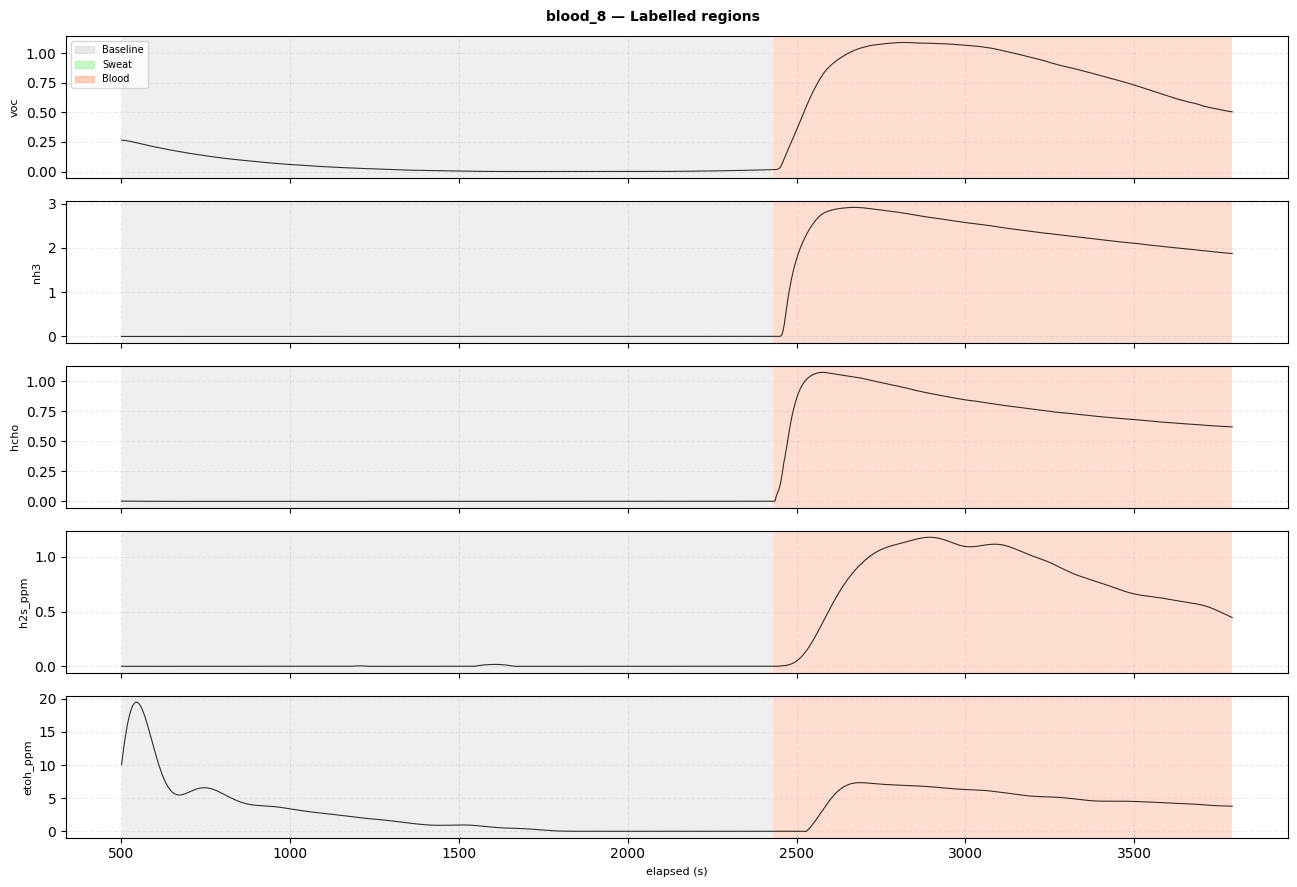

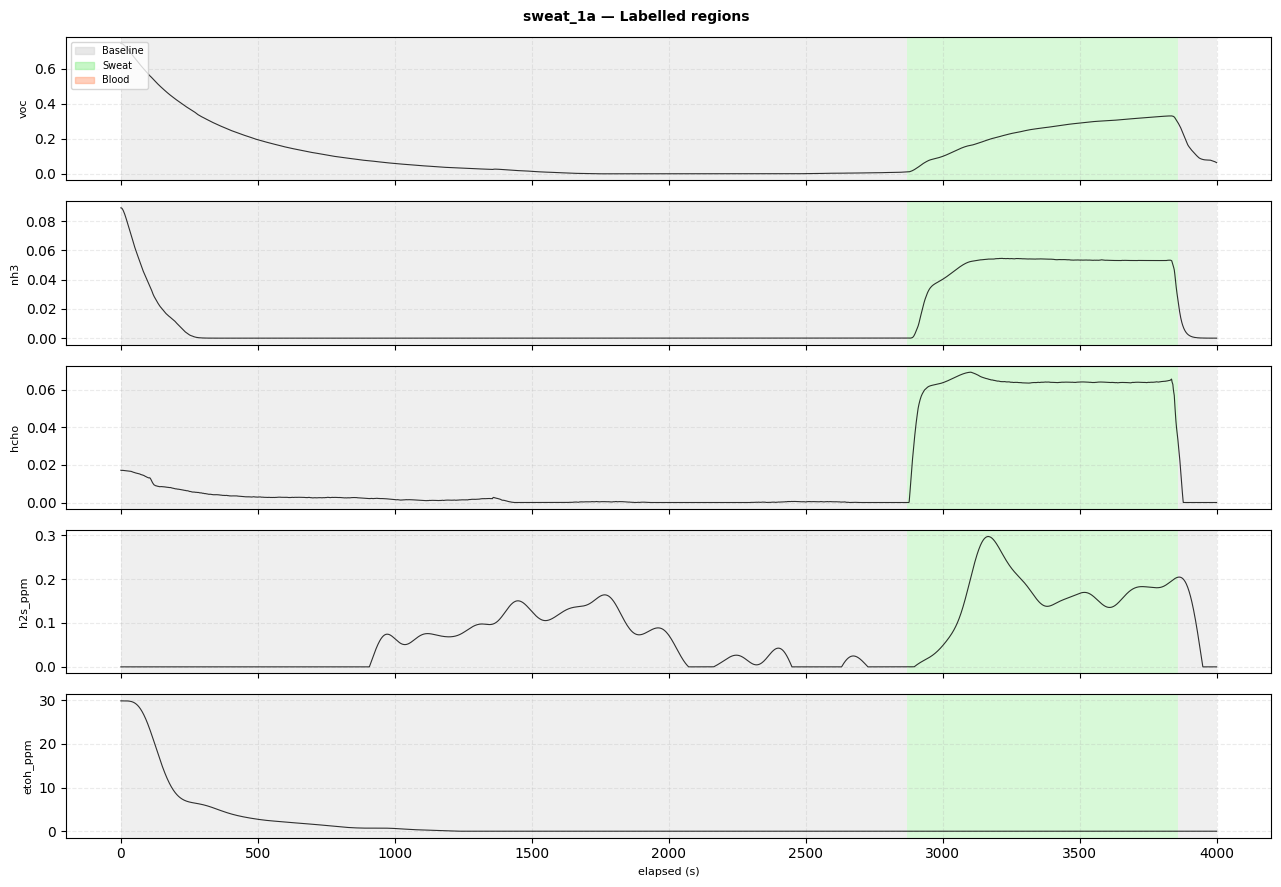

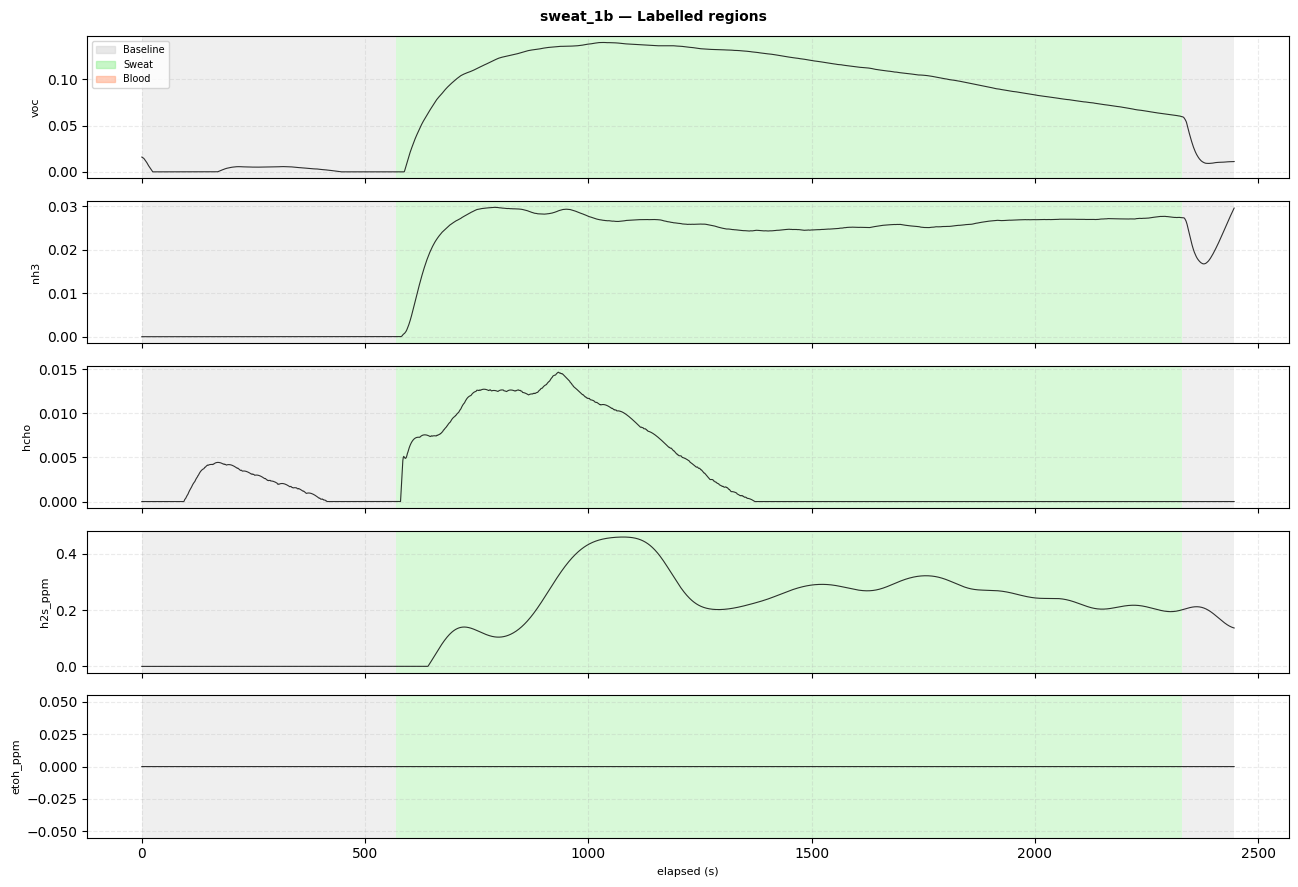

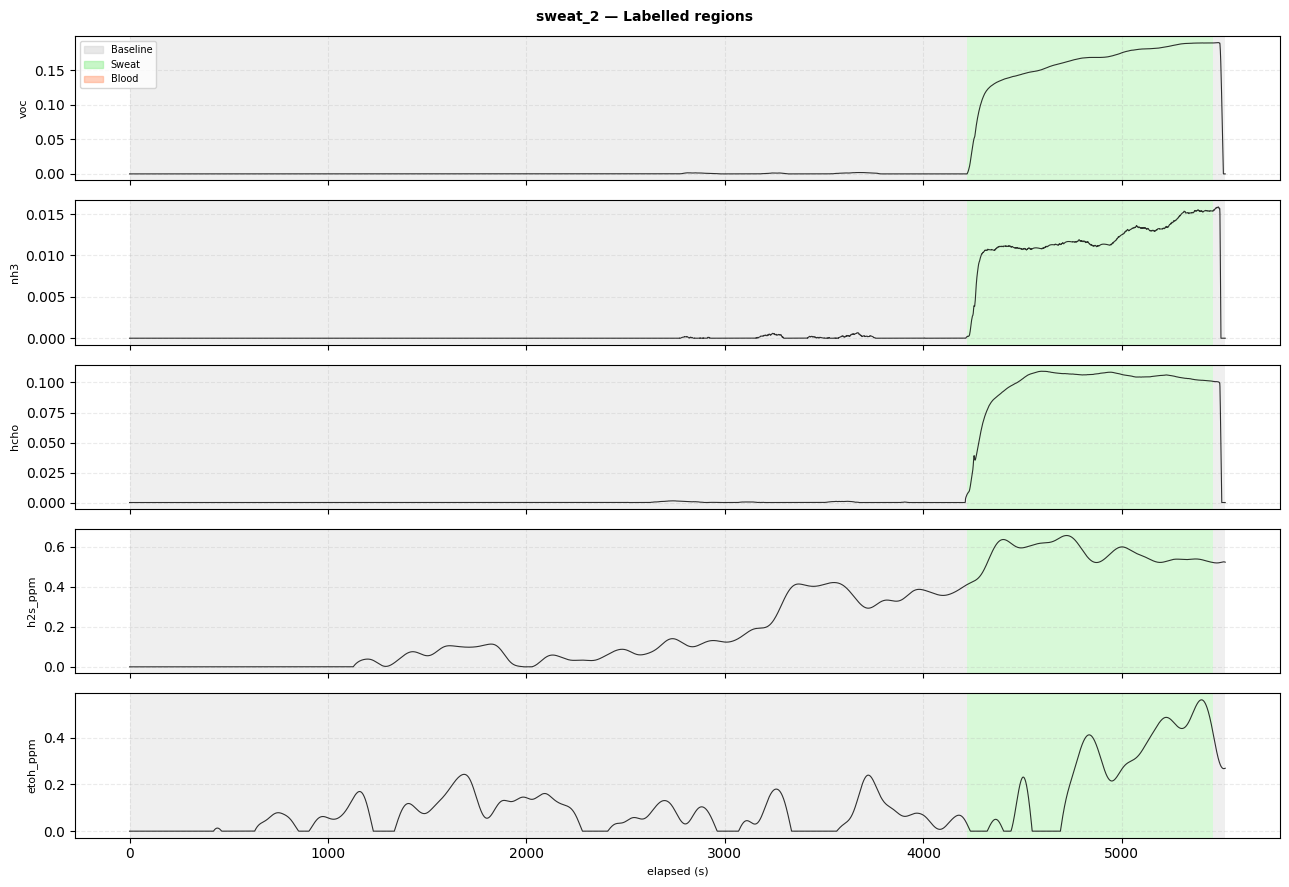

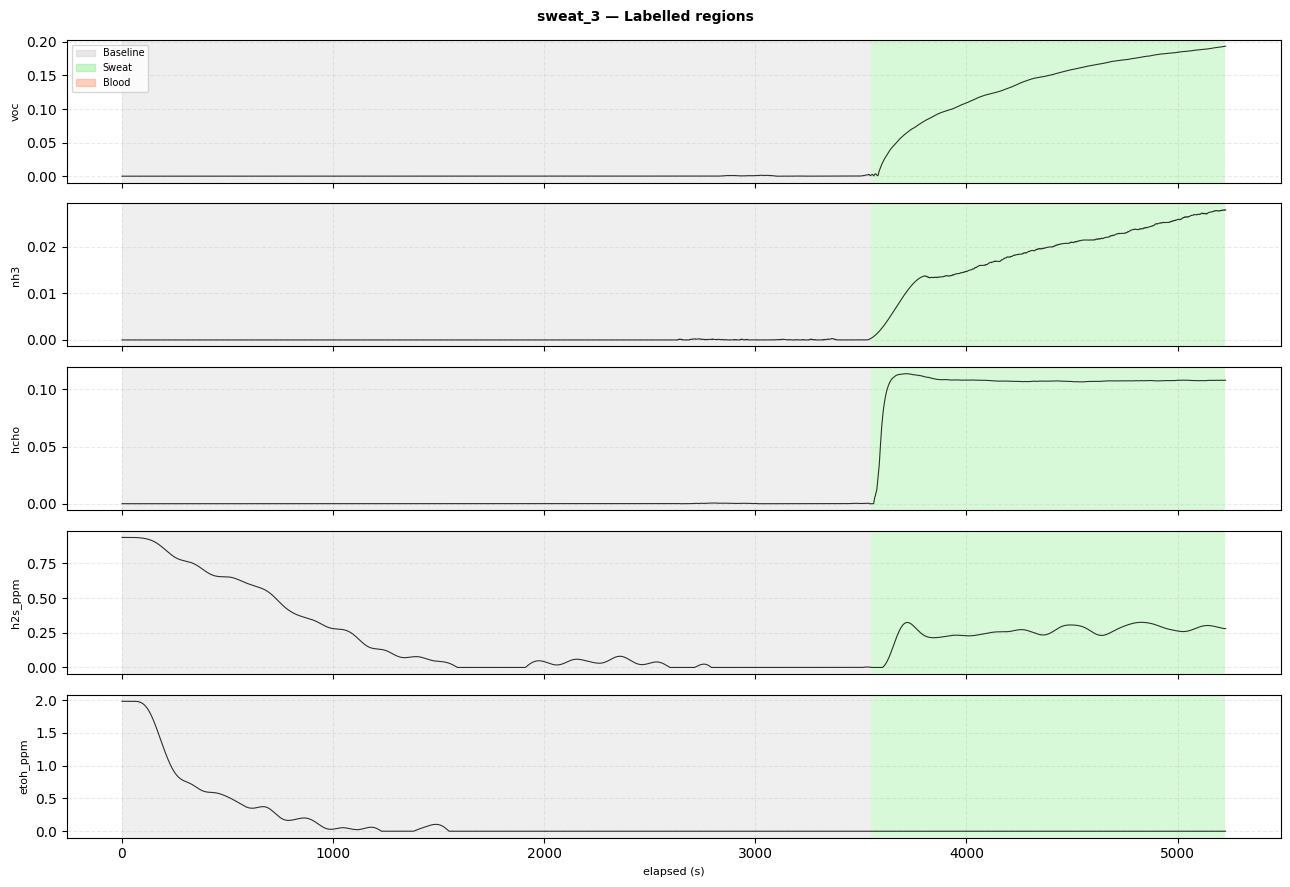

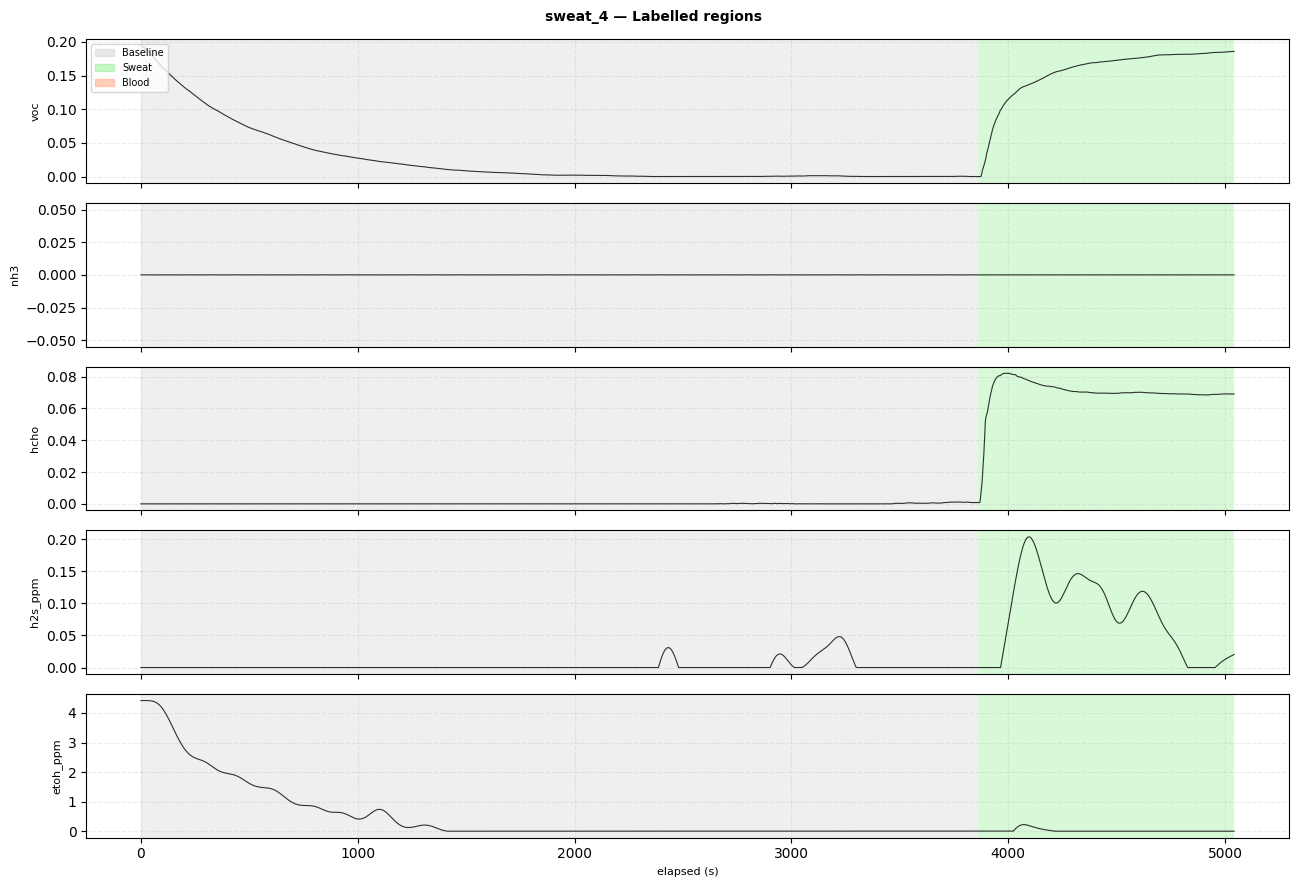

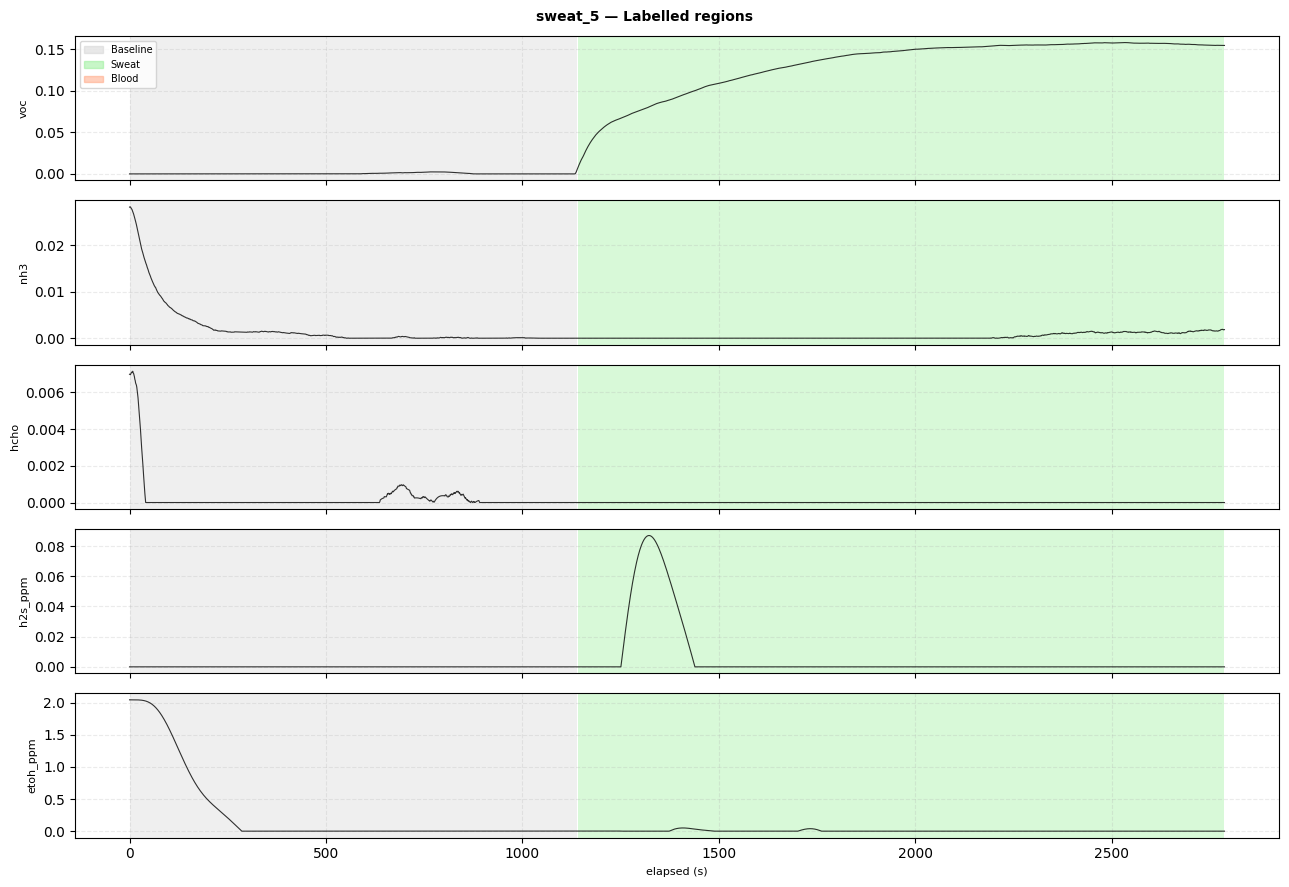

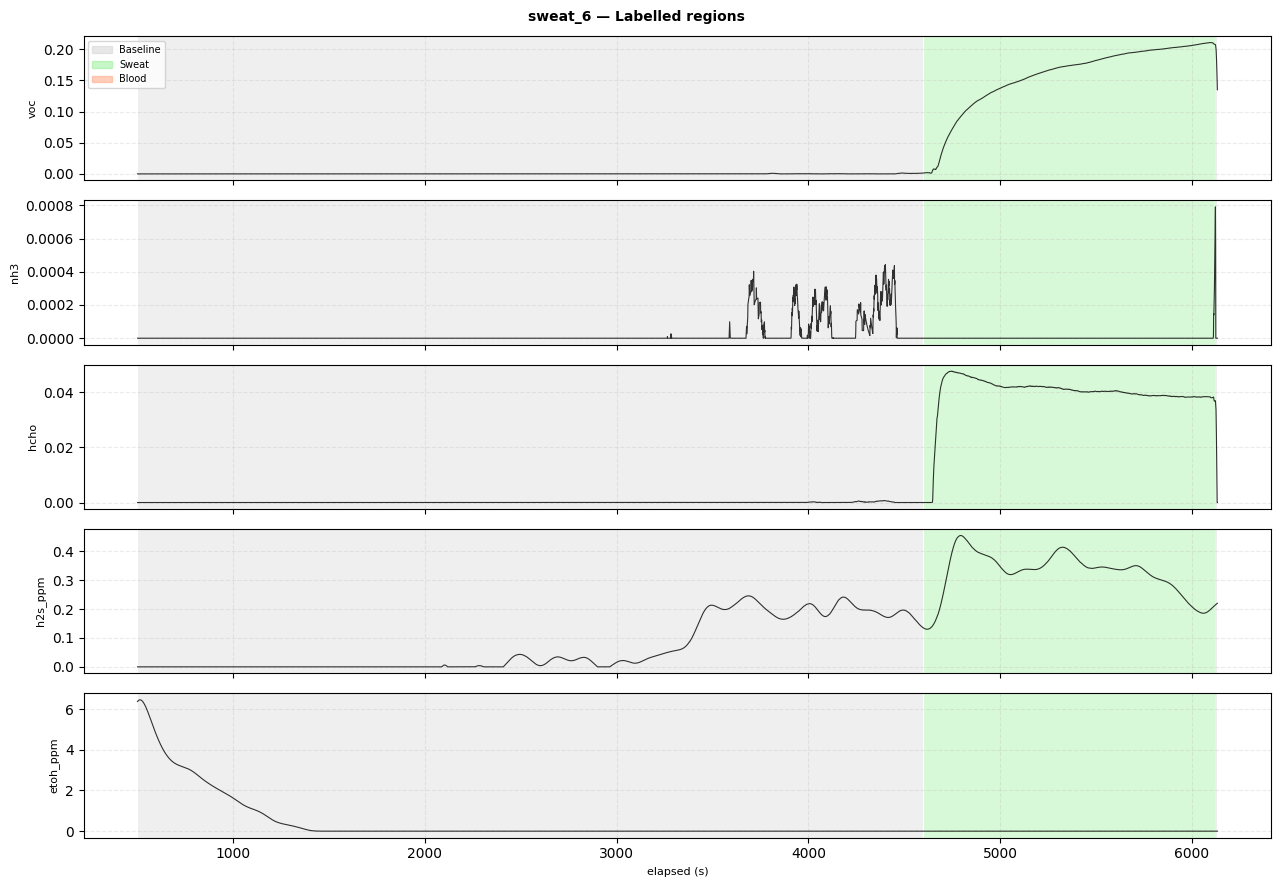

In [160]:
import matplotlib.patches as mpatches

REGION_COLORS = {
    LABEL_BASELINE: ("lightgrey",   "Baseline"),
    LABEL_SWEAT:    ("lightgreen",  "Sweat"),
    LABEL_BLOOD:    ("lightsalmon", "Blood"),
}

PLOT_COLS = ["voc", "nh3", "hcho", "h2s_ppm", "etoh_ppm"]

for key, df in sorted(datasets.items()):
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(13, 9), sharex=True)
    fig.suptitle(f"{key} — Labelled regions", fontsize=10, fontweight="bold")

    # Build contiguous label blocks for shading
    label_blocks = df[["elapsed_s", "label"]].copy()
    label_blocks["block"] = (label_blocks["label"] != label_blocks["label"].shift()).cumsum()
    for _, grp in label_blocks.groupby("block"):
        t0  = grp["elapsed_s"].iloc[0]
        t1  = grp["elapsed_s"].iloc[-1]
        lbl = grp["label"].iloc[0]
        color, _ = REGION_COLORS[lbl]
        for ax in axes:
            ax.axvspan(t0, t1, color=color, alpha=0.35, linewidth=0)

    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.8, color="black", alpha=0.8)
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)

    patches = [mpatches.Patch(color=c, label=l, alpha=0.5)
               for _, (c, l) in REGION_COLORS.items()]
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")

    plt.tight_layout()
    plt.show()

## Feature Engineering

Causal helper columns computed per row from the raw merged channels. All operations use only past data, making them compatible with real-time inference.

| Column pattern | Description |
|---|---|
| `{col}_roc` | Rate of change — instantaneous Δ between consecutive samples (1st derivative) |
| `{col}_acc` | Acceleration — rate of change of ROC (2nd derivative) |
| `{col}_roll_mean_{w}` | Rolling mean over w seconds — signal level at multiple timescales |
| `{col}_roll_std_{w}` | Rolling std over w seconds — local volatility |
| `{col}_roll_roc_{w}` | Rolling mean of \|ROC\| over w seconds — smoothed rate of change |

Applied to: `voc`, `nh3`, `hcho`, `h2s_ppm`, `etoh_ppm`, `rh_pct` at windows of **15 s, 30 s, 60 s**.

In [161]:
import numpy as np

CHANNELS     = ["voc", "nh3", "hcho", "h2s_ppm", "etoh_ppm", "rh_pct"]
ROLL_WINDOWS = [15, 30, 60]   # seconds at 1 Hz

EXCLUDE_COLS = {"elapsed_s", "label", "session", "temp_C"}

for key in datasets:
    df = datasets[key].copy()

    for col in CHANNELS:
        df[f"{col}_roc"] = df[col].diff()
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()

    datasets[key] = df

# FEATURE_COLS defined here — used by downstream modelling cells
_sample = next(iter(datasets.values()))
FEATURE_COLS = [c for c in _sample.columns if c not in EXCLUDE_COLS]

helper_cols = [c for c in FEATURE_COLS if c not in set(ALL_CHANNELS)]
print(f"Sessions processed : {len(datasets)}")
print(f"Helper cols added  : {len(helper_cols)}  per session")
print(f"Total feature cols : {len(FEATURE_COLS)}  (signal + helpers, excl. elapsed/label/temp)")
print(f"\nColumns per session: {len(_sample.columns)}  total")


Sessions processed : 16
Helper cols added  : 66  per session
Total feature cols : 72  (signal + helpers, excl. elapsed/label/temp)

Columns per session: 76  total


## Windowed Feature Extraction

A **60 s non-overlapping window** is slid over each labelled segment independently — windows never cross a label boundary. For each window, four aggregate statistics are extracted per feature column:

| Aggregate | Description |
|---|---|
| `_mean` | Mean signal level over the window |
| `_std` | Standard deviation — within-window volatility |
| `_max` | Peak value |
| `_slope` | Linear trend (fitted slope) |

Applied across all signal and helper columns: `voc`, `nh3`, `hcho`, `h2s_ppm`, `etoh_ppm` and their ROC, acceleration, and rolling variants. Environmental columns (`temp_C`, `rh_pct`) and metadata (`elapsed_s`, `label`, `session`) are excluded.

Each window produces one feature vector with a single class label. Baseline windows are undersampled to match the larger of sweat/blood window counts so the training set is balanced.

In [162]:
WINDOW_SIZE = 60   # seconds = samples at 1 Hz

# FEATURE_COLS and EXCLUDE_COLS are defined in the Feature Engineering cell above
def extract_window_features(window_df, feature_cols):
    features = {}
    t = np.arange(len(window_df))
    for col in feature_cols:
        vals = window_df[col].values
        features[f"{col}_mean"]  = np.nanmean(vals)
        features[f"{col}_std"]   = np.nanstd(vals)
        features[f"{col}_max"]   = np.nanmax(vals)
        slope, _ = np.polyfit(t, vals, 1) if len(vals) > 1 else (0.0, 0.0)
        features[f"{col}_slope"] = slope
    return features

# ── Slide window per (session, label) — never cross label boundaries ──────────
all_windows = []

for session, df in datasets.items():
    for label in [LABEL_BASELINE, LABEL_SWEAT, LABEL_BLOOD]:
        label_df   = df[df["label"] == label].reset_index(drop=True)
        n_windows  = len(label_df) // WINDOW_SIZE
        for i in range(n_windows):
            window = label_df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
            feats  = extract_window_features(window, FEATURE_COLS)
            feats["label"]   = label
            feats["session"] = session
            all_windows.append(feats)

windows_df = pd.DataFrame(all_windows)

# ── Undersample baseline to match larger of sweat / blood ─────────────────────
baseline_w = windows_df[windows_df["label"] == LABEL_BASELINE]
sweat_w    = windows_df[windows_df["label"] == LABEL_SWEAT]
blood_w    = windows_df[windows_df["label"] == LABEL_BLOOD]

n_target         = max(len(sweat_w), len(blood_w))
baseline_sampled = baseline_w.sample(n=min(n_target, len(baseline_w)), random_state=42)
windows_balanced = pd.concat([sweat_w, blood_w, baseline_sampled]).reset_index(drop=True)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Session':<12}  {'Baseline':>10}  {'Sweat':>8}  {'Blood':>8}  {'Total':>8}")
print("-" * 50)
for session in sorted(windows_df["session"].unique()):
    s  = windows_df[windows_df["session"] == session]
    b  = (s["label"] == LABEL_BASELINE).sum()
    sw = (s["label"] == LABEL_SWEAT).sum()
    bl = (s["label"] == LABEL_BLOOD).sum()
    print(f"{session:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(s):>8}")
print("-" * 50)
totals = windows_df.groupby("label").size()
print(f"{'TOTAL':<12}  {totals.get(LABEL_BASELINE,0):>10}  {totals.get(LABEL_SWEAT,0):>8}  {totals.get(LABEL_BLOOD,0):>8}  {len(windows_df):>8}")
print(f"\nBalanced windows : {len(windows_balanced)}  "
      f"(sweat={len(sweat_w)}, blood={len(blood_w)}, baseline={len(baseline_sampled)})")
print(f"Feature columns  : {len(FEATURE_COLS)}")
print(f"Window features  : {len(windows_balanced.columns) - 2}  (×4 aggregates, excl. label/session)")

Session         Baseline     Sweat     Blood     Total
--------------------------------------------------
blood_0               31         0        29        60
blood_1               11         0        20        31
blood_2               28         0        19        47
blood_3               31         0        24        55
blood_4               22         0        17        39
blood_5               28         0        31        59
blood_6               35         0        21        56
blood_7               35         0        23        58
blood_8               31         0        22        53
sweat_1a              49        16         0        65
sweat_1b              11        28         0        39
sweat_2               69        20         0        89
sweat_3               57        27         0        84
sweat_4               62        19         0        81
sweat_5               18        26         0        44
sweat_6               65        24         0        89
--------------

In [163]:
# ── Feature engineering + windowing for held-out test sessions ────────────────
# Mirrors the Feature Engineering and Windowed Feature Extraction cells exactly.
# test_datasets is kept separate so no test information enters windows_balanced.

test_datasets_fe = {}
for key, df in test_datasets.items():
    df = df.copy()
    for col in CHANNELS:
        df[f"{col}_roc"] = df[col].diff()
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()
    test_datasets_fe[key] = df

# Apply labels
for key, df in test_datasets_fe.items():
    test_datasets_fe[key]["label"] = LABEL_BASELINE
    for t_start, t_end, lbl in SAMPLE_WINDOWS.get(key, []):
        t = df["elapsed_s"]
        mask = (t >= t_start) & (t <= t_end)
        test_datasets_fe[key].loc[mask, "label"] = lbl

# Window extraction — include t_start/t_end for plotting
test_windows = []
for session, df in test_datasets_fe.items():
    for label in [LABEL_BASELINE, LABEL_SWEAT, LABEL_BLOOD]:
        label_df  = df[df["label"] == label].reset_index(drop=True)
        n_windows = len(label_df) // WINDOW_SIZE
        for i in range(n_windows):
            window = label_df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
            feats  = extract_window_features(window, FEATURE_COLS)
            feats["label"]   = label
            feats["session"] = session
            feats["t_start"] = window["elapsed_s"].iloc[0]
            feats["t_end"]   = window["elapsed_s"].iloc[-1]
            test_windows.append(feats)

test_windows_df = pd.DataFrame(test_windows)

print(f"{'Session':<12}  {'Baseline':>10}  {'Sweat':>8}  {'Blood':>8}  {'Total':>8}")
print("-" * 50)
for session in sorted(test_windows_df["session"].unique()):
    s  = test_windows_df[test_windows_df["session"] == session]
    b  = (s["label"] == LABEL_BASELINE).sum()
    sw = (s["label"] == LABEL_SWEAT).sum()
    bl = (s["label"] == LABEL_BLOOD).sum()
    print(f"{session:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(s):>8}")
print(f"\nTest windows total: {len(test_windows_df)}")


Session         Baseline     Sweat     Blood     Total
--------------------------------------------------
blood_9               37         0        30        67
sweat_7               28        30         0        58

Test windows total: 125


## Training and Evaluation

**Model:** Random Forest (200 trees, `class_weight="balanced"`)

**Feature selection:** A preliminary Random Forest is fit on all training windows. Features with importance below the mean are dropped via `SelectFromModel`.

**Validation:** Stratified 80/20 split on `windows_balanced` — 80% train, 20% validate, split by label proportion.

**Final model:** Retrained on all training windows with selected features. Evaluated on `sweat_7` and `blood_9` — the two sessions removed before any processing.


In [164]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

X      = windows_balanced.drop(columns=["label", "session"])
y      = windows_balanced["label"]
groups = windows_balanced["session"]

# ── Feature selection — fit preliminary RF, keep above-mean importance ─────────
pre_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                random_state=42, n_jobs=-1)
pre_rf.fit(X, y)

selector      = SelectFromModel(pre_rf, prefit=True, threshold="mean")
selected_cols = X.columns[selector.get_support()].tolist()
X_sel         = pd.DataFrame(selector.transform(X), columns=selected_cols, index=X.index)

print(f"Feature selection: {len(selected_cols)} / {len(X.columns)} features retained\n")

# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_val, y_train, y_val, grp_train, grp_val = train_test_split(
    X_sel, y, groups,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.3f}  ({len(X_val)} windows)\n")
print(classification_report(
    y_val, y_val_pred,
    target_names=["baseline", "sweat", "blood"],
    zero_division=0,
))

# ── Final model on all training windows ───────────────────────────────────────
final_model = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                     random_state=42, n_jobs=-1)
final_model.fit(X_sel, y)
print(f"Final model trained on {len(X_sel)} windows, {len(selected_cols)} features.")


Feature selection: 50 / 288 features retained

Validation accuracy: 0.991  (115 windows)

              precision    recall  f1-score   support

    baseline       1.00      0.98      0.99        42
       sweat       1.00      1.00      1.00        32
       blood       0.98      1.00      0.99        41

    accuracy                           0.99       115
   macro avg       0.99      0.99      0.99       115
weighted avg       0.99      0.99      0.99       115

Final model trained on 572 windows, 50 features.


### Feature Importances

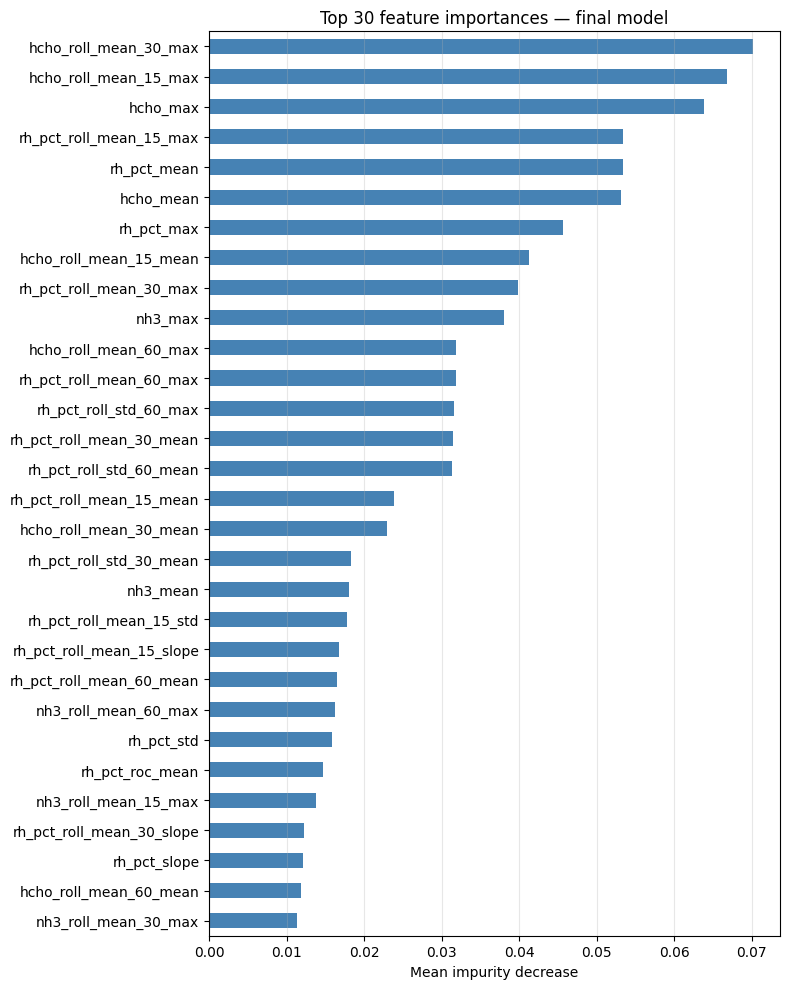

Top 10:
  hcho_roll_mean_30_max                          0.0701
  hcho_roll_mean_15_max                          0.0669
  hcho_max                                       0.0639
  rh_pct_roll_mean_15_max                        0.0534
  rh_pct_mean                                    0.0534
  hcho_mean                                      0.0531
  rh_pct_max                                     0.0457
  hcho_roll_mean_15_mean                         0.0413
  rh_pct_roll_mean_30_max                        0.0398
  nh3_max                                        0.0381


In [165]:
importances = pd.Series(
    final_model.feature_importances_, index=selected_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
importances.tail(30).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean impurity decrease")
ax.set_title("Top 30 feature importances — final model")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10:")
for feat, imp in importances.iloc[::-1].head(10).items():
    print(f"  {feat:<45}  {imp:.4f}")


## Test — sweat_7 and blood_9

Apply the final model to the two held-out sessions. For each session:
- Per-window prediction with confidence score
- Prediction percentage breakdown across all three labels
- Overall accuracy against ground-truth labels
- Signal plot with predicted class shaded per window



  BLOOD_9
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    2       61s    122s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    3      123s    183s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    4      184s    245s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    5      246s    306s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    6      307s    367s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    7      368s    429s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    8      430s    490s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
    9      491s    552s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
   10      553s    613s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
   11      614s    675s    baseline    baseline  65.5%  0.66 / 0.10 / 0.24
   12      676s  

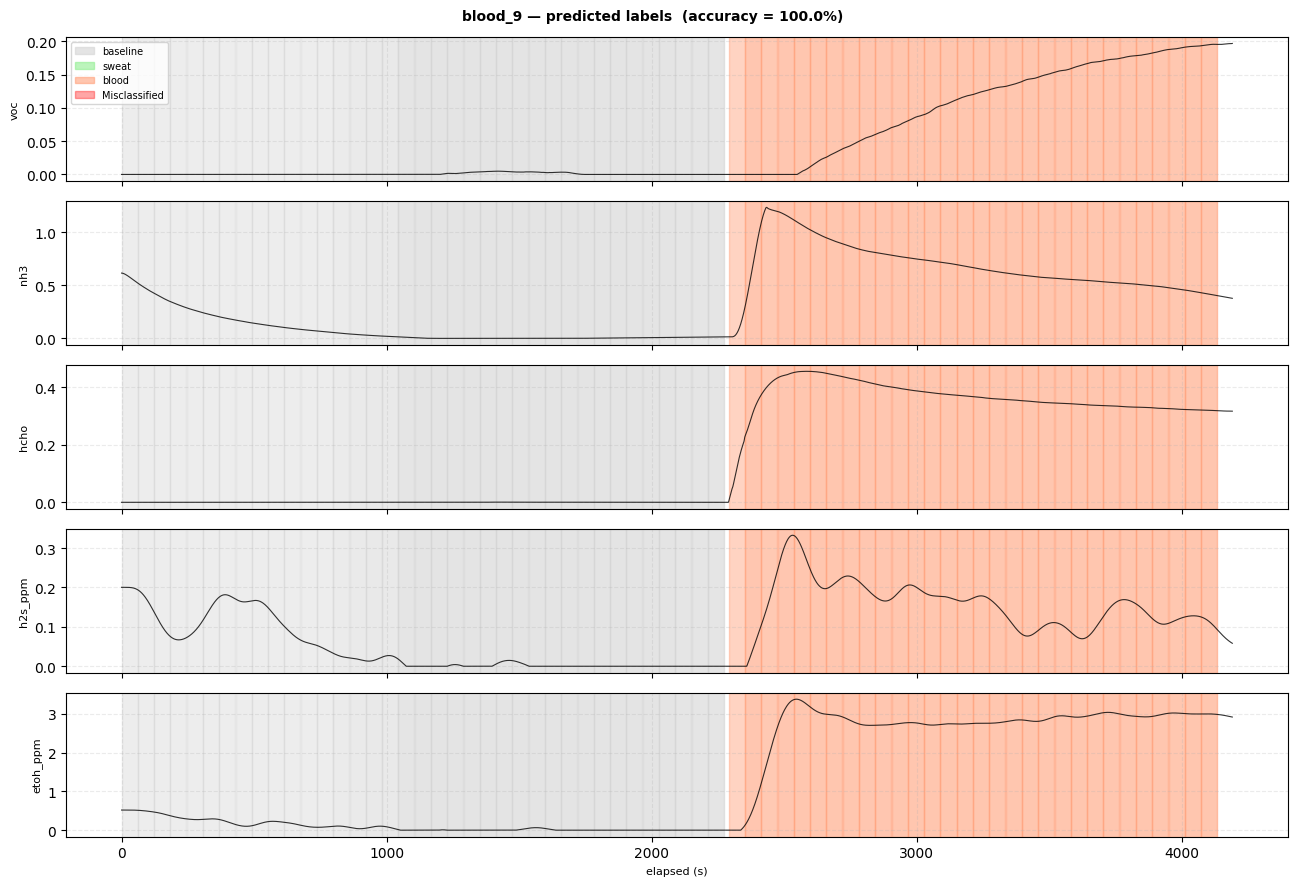


  SWEAT_7
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline       sweat  65.5%  0.34 / 0.66 / 0.01  ✗
    2       61s    123s    baseline       sweat  83.0%  0.17 / 0.83 / 0.01  ✗
    3      124s    185s    baseline       sweat  83.0%  0.17 / 0.83 / 0.01  ✗
    4      186s    247s    baseline       sweat  83.0%  0.17 / 0.83 / 0.01  ✗
    5      248s    308s    baseline       sweat  82.0%  0.17 / 0.82 / 0.01  ✗
    6      309s    370s    baseline       sweat  63.0%  0.36 / 0.63 / 0.01  ✗
    7      371s    432s    baseline    baseline  53.5%  0.54 / 0.45 / 0.01
    8      433s    495s    baseline    baseline  53.5%  0.54 / 0.45 / 0.01
    9      496s    558s    baseline    baseline  53.5%  0.54 / 0.45 / 0.01
   10      559s    622s    baseline    baseline  53.5%  0.54 / 0.45 / 0.01
   11      623s    684s    baseline    baseline  53.5%  0.54 / 0.45 / 0.01

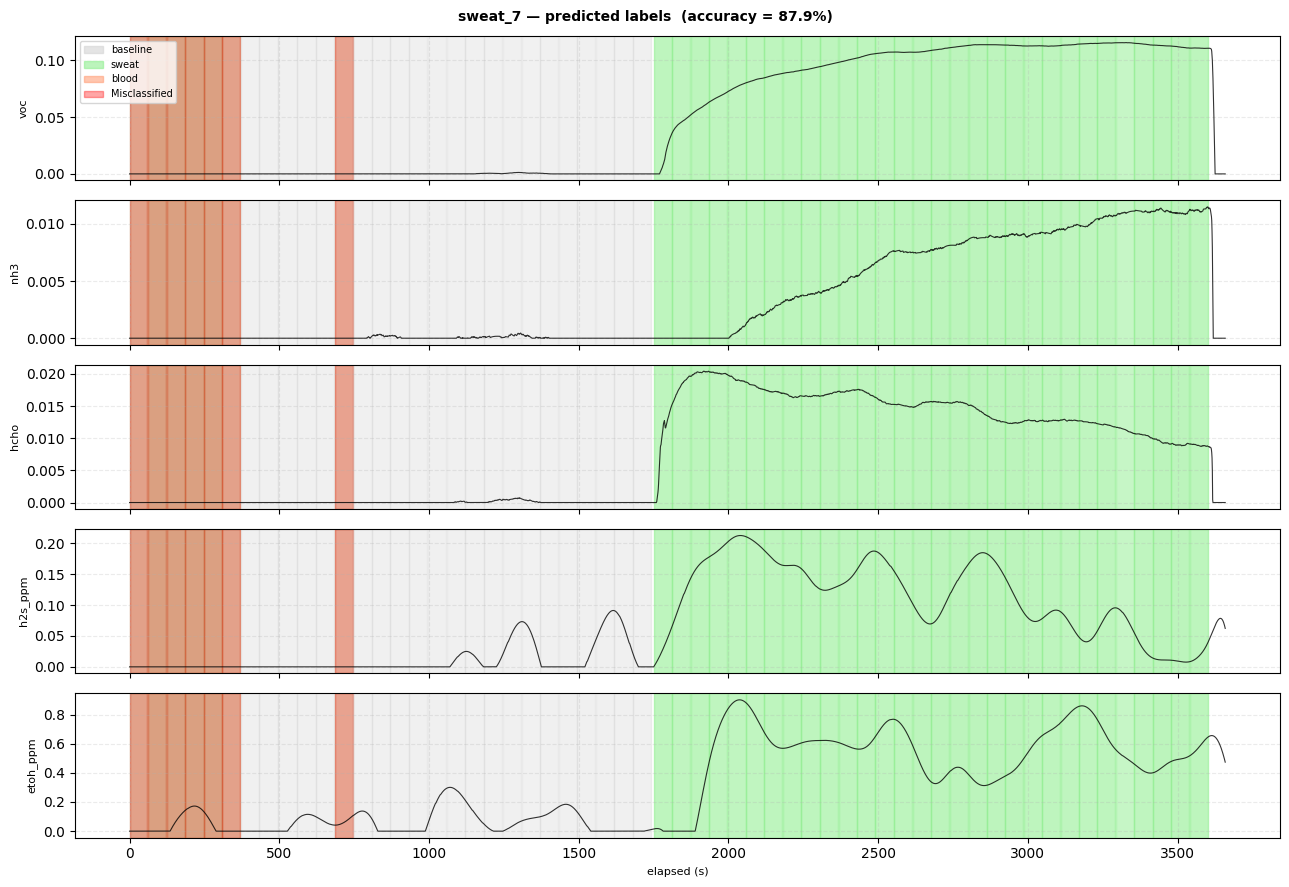

In [166]:
import matplotlib.patches as mpatches

CLASS_NAMES = {LABEL_BASELINE: "baseline", LABEL_SWEAT: "sweat", LABEL_BLOOD: "blood"}
PRED_COLORS = {LABEL_BASELINE: "lightgrey", LABEL_SWEAT: "lightgreen", LABEL_BLOOD: "lightsalmon"}

def _window_bounds(sess):
    """Reconstruct (t_start, t_end, true_label) for each window in a test session."""
    df = test_datasets_fe[sess]
    bounds = []
    for label in [LABEL_BASELINE, LABEL_SWEAT, LABEL_BLOOD]:
        label_df  = df[df["label"] == label].reset_index(drop=True)
        n_windows = len(label_df) // WINDOW_SIZE
        for i in range(n_windows):
            w = label_df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
            bounds.append({"t_start": w["elapsed_s"].iloc[0],
                           "t_end":   w["elapsed_s"].iloc[-1],
                           "label":   label})
    return pd.DataFrame(bounds)

for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    X_sess = wins_s[selected_cols]
    y_true = wins_s["label"].reset_index(drop=True)
    bounds = _window_bounds(sess)

    preds  = final_model.predict(X_sess)
    probas = final_model.predict_proba(X_sess)   # columns: [baseline, sweat, blood]

    # ── Per-window table ──────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"  {sess.upper()}")
    print(f"{'='*70}")
    print(f"  {'#':>3}  {'t_start':>8}  {'t_end':>6}  {'True':>10}  {'Predicted':>10}  {'Conf':>6}  base / sweat / blood")
    print(f"  {'-'*66}")
    for i in range(len(wins_s)):
        t0   = bounds.loc[i, "t_start"]
        t1   = bounds.loc[i, "t_end"]
        true = CLASS_NAMES[y_true.iloc[i]]
        pred = CLASS_NAMES[preds[i]]
        conf = probas[i].max()
        p    = probas[i]
        mark = "  ✗" if preds[i] != y_true.iloc[i] else ""
        print(f"  {i+1:>3}  {t0:>7.0f}s  {t1:>5.0f}s  {true:>10}  {pred:>10}  {conf:>5.1%}  "
              f"{p[0]:.2f} / {p[1]:.2f} / {p[2]:.2f}{mark}")

    # ── Accuracy and prediction % breakdown ───────────────────────────────────
    n_correct = (preds == y_true.values).sum()
    n_total   = len(preds)
    acc       = n_correct / n_total
    print(f"\n  Accuracy: {acc:.1%}  ({n_correct}/{n_total} windows correct)")
    print(f"\n  Prediction breakdown (% of all {n_total} windows predicted as each class):")
    for lbl, name in CLASS_NAMES.items():
        count = (preds == lbl).sum()
        pct   = count / n_total
        bar   = "█" * int(pct * 30)
        print(f"    {name:<10}  {pct:>5.1%}  {bar}  ({count} windows)")

    # ── Signal plot ───────────────────────────────────────────────────────────
    df_sess = test_datasets_fe[sess]
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(13, 9), sharex=True)
    fig.suptitle(f"{sess} — predicted labels  (accuracy = {acc:.1%})",
                 fontsize=10, fontweight="bold")

    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df_sess["elapsed_s"], df_sess[col], color="black", linewidth=0.8, alpha=0.8)
        for i in range(len(bounds)):
            t0   = bounds.loc[i, "t_start"]
            t1   = bounds.loc[i, "t_end"]
            pred = preds[i]
            conf = probas[i].max()
            true = bounds.loc[i, "label"]
            ax.axvspan(t0, t1, alpha=conf * 0.6, color=PRED_COLORS[pred])
            if pred != true:
                ax.axvspan(t0, t1, alpha=0.35, color="red")
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    patches = [mpatches.Patch(color=c, label=CLASS_NAMES[lbl], alpha=0.6)
               for lbl, c in PRED_COLORS.items()]
    patches.append(mpatches.Patch(color="red", alpha=0.35, label="Misclassified"))
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")
    plt.tight_layout()
    plt.show()


## Investigation — Misclassified Windows

### How to read the bar chart

Each panel is one of the top 10 features by importance, showing three groups:

| Bar | Meaning |
|-----|---------|
| **Blue** | Correct baseline windows |
| **Red** | Misclassified baseline windows (true baseline, predicted as sweat/blood) |
| **Green** | Correct sample windows (sweat or blood) |

If red leans toward green, that feature is driving the wrong prediction. If red ≈ blue, it is not the culprit.

---

### Findings

**Red ≈ Blue across all 10 panels** — the top 10 features are not the cause. The misclassification is driven by lower-ranked features outside the top 10 whose combined vote tips the forest toward sweat.

The early windows (t = 0–370s) have HCHO = 0 and rh_pct ~45%. The zero HCHO is the likely trigger — the model learned from training sessions with flat HCHO during sweat exposure and associates it with sweat. The humidity at 45% is below even the baseline mean and should lean away from sweat; it was also elevated that day due to rain, making it an unreliable signal for this session.


blood_9: no misclassifications


  SWEAT_7 — 7 misclassified window(s)

  Window 1  |  t = 0–60s  |  true=baseline  predicted=sweat  conf=65.5%
  Probabilities: baseline=0.34  sweat=0.66  blood=0.01

  Feature                                      This window  Correct baseline   Sample mean
  --------------------------------------------------------------------------------------
  hcho_roll_mean_30_max                            0.00000           0.00010       0.01504  ↓
  hcho_roll_mean_15_max                            0.00000           0.00010       0.01505  ↓
  hcho_max                                         0.00000           0.00011       0.01508  ↓
  rh_pct_roll_mean_15_max                         45.23333          47.04222      67.59867   
  rh_pct_mean                                     45.11333          47.02222      67.15628   
  hcho_mean                                        0.00000           0.00005       0.01449  ↓
  rh_pct_max                                      45.300

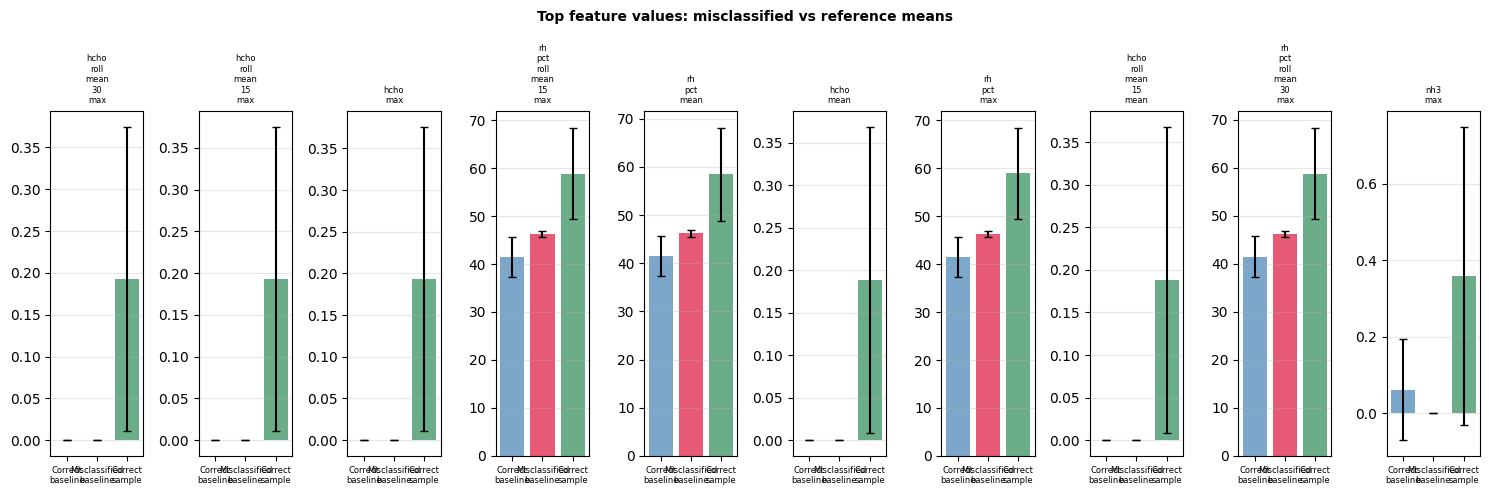

In [167]:
TOP_N = 10  # top features by importance to inspect

top_feats = importances.iloc[::-1].head(TOP_N).index.tolist()

for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    bounds = _window_bounds(sess)
    X_sess = wins_s[selected_cols]
    y_true = wins_s["label"].reset_index(drop=True)

    preds  = final_model.predict(X_sess)
    probas = final_model.predict_proba(X_sess)

    misclassified = [i for i in range(len(wins_s)) if preds[i] != y_true.iloc[i]]
    if not misclassified:
        print(f"{sess}: no misclassifications\n")
        continue

    # Reference means from correctly classified windows
    correct_mask    = np.array([preds[i] == y_true.iloc[i] for i in range(len(wins_s))])
    baseline_mask   = correct_mask & (y_true == LABEL_BASELINE).values
    sample_lbl      = LABEL_SWEAT if "sweat" in sess else LABEL_BLOOD
    sample_mask     = correct_mask & (y_true == sample_lbl).values

    ref_baseline = X_sess[baseline_mask][top_feats].mean() if baseline_mask.any() else None
    ref_sample   = X_sess[sample_mask][top_feats].mean()   if sample_mask.any()   else None

    print(f"\n{'='*72}")
    print(f"  {sess.upper()} — {len(misclassified)} misclassified window(s)")
    print(f"{'='*72}")

    for i in misclassified:
        t0   = bounds.loc[i, "t_start"]
        t1   = bounds.loc[i, "t_end"]
        true = CLASS_NAMES[y_true.iloc[i]]
        pred = CLASS_NAMES[preds[i]]
        conf = probas[i].max()
        p    = probas[i]

        print(f"\n  Window {i+1}  |  t = {t0:.0f}–{t1:.0f}s  |  true={true}  predicted={pred}  conf={conf:.1%}")
        print(f"  Probabilities: baseline={p[0]:.2f}  sweat={p[1]:.2f}  blood={p[2]:.2f}")
        print(f"\n  {'Feature':<42}  {'This window':>12}  {'Correct baseline':>16}  {'Sample mean':>12}")
        print(f"  {'-'*86}")
        row = X_sess.iloc[i]
        for f in top_feats:
            val  = row[f]
            base = ref_baseline[f] if ref_baseline is not None else float("nan")
            samp = ref_sample[f]   if ref_sample   is not None else float("nan")
            diff = "↑" if val > base * 1.5 else ("↓" if val < base * 0.5 else " ")
            print(f"  {f:<42}  {val:>12.5f}  {base:>16.5f}  {samp:>12.5f}  {diff}")

# ── Visual: misclassified window features vs baseline/sample means ────────────
fig, axes = plt.subplots(1, len(top_feats), figsize=(max(14, len(top_feats) * 1.5), 5))
fig.suptitle("Top feature values: misclassified vs reference means", fontsize=10, fontweight="bold")

for ax, feat in zip(axes, top_feats):
    vals = {"Correct\nbaseline": [], "Misclassified\nbaseline": [], "Correct\nsample": []}
    for sess in sorted(test_windows_df["session"].unique()):
        mask   = (test_windows_df["session"] == sess).values
        wins_s = test_windows_df[mask].reset_index(drop=True)
        X_sess = wins_s[selected_cols]
        y_true = wins_s["label"].reset_index(drop=True)
        preds  = final_model.predict(X_sess)
        sample_lbl = LABEL_SWEAT if "sweat" in sess else LABEL_BLOOD

        for i in range(len(wins_s)):
            correct = preds[i] == y_true.iloc[i]
            if correct and y_true.iloc[i] == LABEL_BASELINE:
                vals["Correct\nbaseline"].append(X_sess.iloc[i][feat])
            elif not correct and y_true.iloc[i] == LABEL_BASELINE:
                vals["Misclassified\nbaseline"].append(X_sess.iloc[i][feat])
            elif correct and y_true.iloc[i] == sample_lbl:
                vals["Correct\nsample"].append(X_sess.iloc[i][feat])

    colors = ["steelblue", "crimson", "seagreen"]
    for j, (label, data) in enumerate(vals.items()):
        if data:
            ax.bar(j, np.mean(data), color=colors[j], alpha=0.7,
                   yerr=np.std(data) if len(data) > 1 else 0, capsize=3)
    ax.set_xticks(range(3))
    ax.set_xticklabels(list(vals.keys()), fontsize=6)
    ax.set_title(feat.replace("_", "\n"), fontsize=6)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Model Run 2 — Top-N Feature Selection

Instead of a threshold, hard-code the number of features to keep. Features are ranked by importance from the preliminary RF and only the top N are passed to the model. Adjust `N_FEATURES_R2` to find the right balance between accuracy and reduced noise.


In [172]:
N_FEATURES_R2 = 20  # ← adjust this number

# ── Feature selection — top-N by importance ───────────────────────────────────
importance_series = pd.Series(pre_rf.feature_importances_, index=X.columns)
selected_cols_r2  = importance_series.nlargest(N_FEATURES_R2).index.tolist()
X_sel_r2          = X[selected_cols_r2]

print(f"Run 1 features : {len(selected_cols)}   (threshold = mean importance)")
print(f"Run 2 features : {len(selected_cols_r2)}  (top-{N_FEATURES_R2} by importance)")
print(f"\nSelected features:")
for f in selected_cols_r2:
    print(f"  {f:<45}  {importance_series[f]:.5f}")

# ── 80/20 stratified validation ───────────────────────────────────────────────
X_train_r2, X_val_r2, y_train_r2, y_val_r2 = train_test_split(
    X_sel_r2, y, test_size=0.2, random_state=42, stratify=y
)

model_r2 = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
model_r2.fit(X_train_r2, y_train_r2)

y_val_pred_r2 = model_r2.predict(X_val_r2)
print(f"\nValidation accuracy: {accuracy_score(y_val_r2, y_val_pred_r2):.3f}  ({len(X_val_r2)} windows)")
print(classification_report(y_val_r2, y_val_pred_r2,
                             target_names=["baseline", "sweat", "blood"], zero_division=0))

# ── Final model on all training windows ───────────────────────────────────────
final_model_r2 = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                        random_state=42, n_jobs=-1)
final_model_r2.fit(X_sel_r2, y)
print(f"Final model R2 trained on {len(X_sel_r2)} windows, {len(selected_cols_r2)} features.")


Run 1 features : 50   (threshold = mean importance)
Run 2 features : 20  (top-20 by importance)

Selected features:
  hcho_roll_mean_30_mean                         0.03935
  hcho_max                                       0.03855
  nh3_roll_mean_30_max                           0.03750
  rh_pct_max                                     0.03377
  rh_pct_mean                                    0.03358
  hcho_roll_mean_30_max                          0.03339
  hcho_roll_mean_15_max                          0.02718
  hcho_roll_mean_60_max                          0.02683
  rh_pct_roll_std_60_max                         0.02625
  rh_pct_roll_mean_30_mean                       0.02519
  rh_pct_roll_std_30_max                         0.02385
  rh_pct_roll_mean_30_max                        0.02362
  nh3_max                                        0.02354
  rh_pct_roll_std_60_mean                        0.02353
  hcho_roll_mean_15_mean                         0.02134
  rh_pct_roll_std_30_mean    

### Run 2 — Test on sweat_7 and blood_9

────────────────────────────────────────────────────────────────────────
  TEST RESULTS — Run 1 vs Run 2
────────────────────────────────────────────────────────────────────────
  Session        Run 1 acc   Run 2 acc    Change
  ----------------------------------------------
  blood_9           100.0%      100.0%     +0.0%
  sweat_7            87.9%       89.7%     +1.7%

  BLOOD_9 — Run 2  (accuracy = 100.0%)
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline    baseline  74.5%  0.74 / 0.12 / 0.14
    2       61s    122s    baseline    baseline  74.5%  0.74 / 0.12 / 0.14
    3      123s    183s    baseline    baseline  74.5%  0.74 / 0.12 / 0.14
    4      184s    245s    baseline    baseline  74.5%  0.74 / 0.12 / 0.14
    5      246s    306s    baseline    baseline  74.5%  0.74 / 0.12 / 0.14
    6      307s    367s    baseline    baseline  74.5%  0.74 / 0

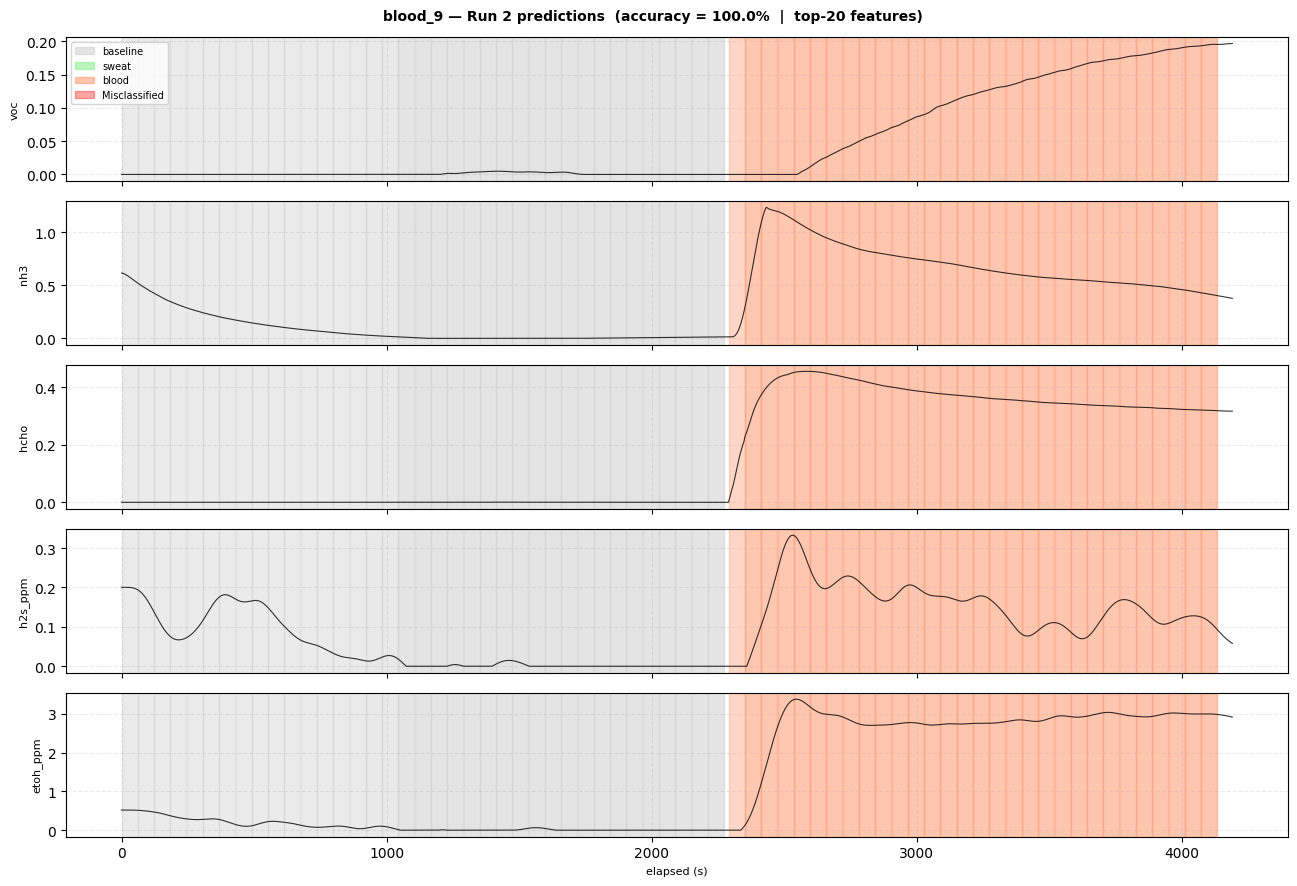


  SWEAT_7 — Run 2  (accuracy = 89.7%)
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline       sweat  56.0%  0.43 / 0.56 / 0.01  ✗
    2       61s    123s    baseline       sweat  92.5%  0.07 / 0.93 / 0.00  ✗
    3      124s    185s    baseline       sweat  93.0%  0.07 / 0.93 / 0.00  ✗
    4      186s    247s    baseline       sweat  93.5%  0.07 / 0.94 / 0.00  ✗
    5      248s    308s    baseline       sweat  89.0%  0.11 / 0.89 / 0.00  ✗
    6      309s    370s    baseline       sweat  73.0%  0.26 / 0.73 / 0.01  ✗
    7      371s    432s    baseline    baseline  54.0%  0.54 / 0.44 / 0.02
    8      433s    495s    baseline    baseline  54.0%  0.54 / 0.44 / 0.02
    9      496s    558s    baseline    baseline  54.0%  0.54 / 0.44 / 0.02
   10      559s    622s    baseline    baseline  54.0%  0.54 / 0.44 / 0.02
   11      623s    684s    baseline    baselin

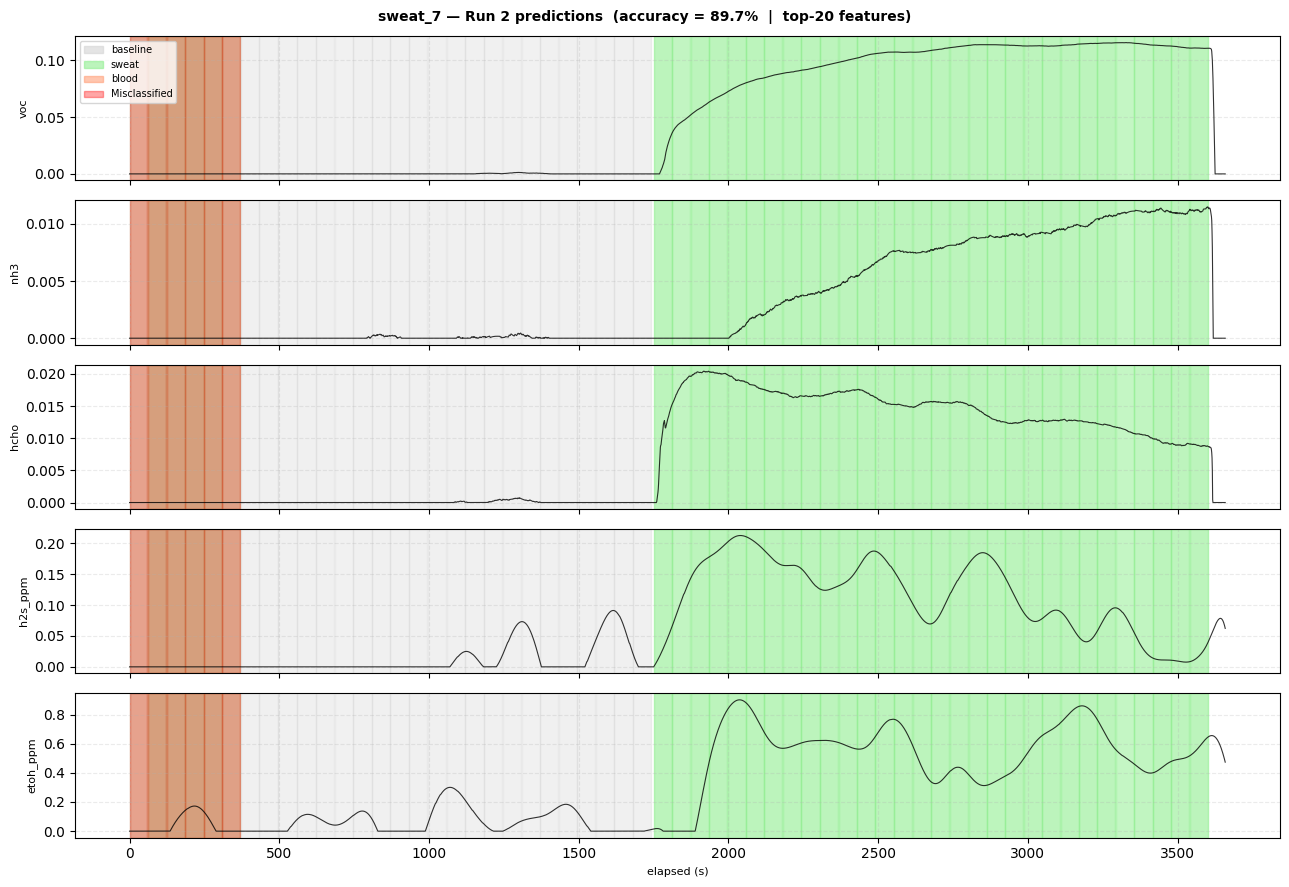

In [173]:
# ── Run 1 vs Run 2 accuracy comparison ───────────────────────────────────────
print(f"{'─'*72}")
print(f"  TEST RESULTS — Run 1 vs Run 2")
print(f"{'─'*72}")
print(f"  {'Session':<12}  {'Run 1 acc':>10}  {'Run 2 acc':>10}  {'Change':>8}")
print(f"  {'-'*46}")

for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    y_true = wins_s["label"].reset_index(drop=True)

    acc_r1 = accuracy_score(y_true, final_model.predict(wins_s[selected_cols]))
    acc_r2 = accuracy_score(y_true, final_model_r2.predict(wins_s[selected_cols_r2]))

    delta = acc_r2 - acc_r1
    sign  = f"+{delta:.1%}" if delta >= 0 else f"{delta:.1%}"
    print(f"  {sess:<12}  {acc_r1:>10.1%}  {acc_r2:>10.1%}  {sign:>8}")

# ── Per-window breakdown and signal plot ──────────────────────────────────────
for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    bounds = _window_bounds(sess)
    X_sess = wins_s[selected_cols_r2]
    y_true = wins_s["label"].reset_index(drop=True)

    preds_r2  = final_model_r2.predict(X_sess)
    probas_r2 = final_model_r2.predict_proba(X_sess)

    n_correct = (preds_r2 == y_true.values).sum()
    n_total   = len(preds_r2)
    acc       = n_correct / n_total

    print(f"\n{'='*70}")
    print(f"  {sess.upper()} — Run 2  (accuracy = {acc:.1%})")
    print(f"{'='*70}")
    print(f"  {'#':>3}  {'t_start':>8}  {'t_end':>6}  {'True':>10}  {'Predicted':>10}  {'Conf':>6}  base / sweat / blood")
    print(f"  {'-'*66}")
    for i in range(len(wins_s)):
        t0   = bounds.loc[i, "t_start"]
        t1   = bounds.loc[i, "t_end"]
        true = CLASS_NAMES[y_true.iloc[i]]
        pred = CLASS_NAMES[preds_r2[i]]
        conf = probas_r2[i].max()
        p    = probas_r2[i]
        mark = "  ✗" if preds_r2[i] != y_true.iloc[i] else ""
        print(f"  {i+1:>3}  {t0:>7.0f}s  {t1:>5.0f}s  {true:>10}  {pred:>10}  {conf:>5.1%}  "
              f"{p[0]:.2f} / {p[1]:.2f} / {p[2]:.2f}{mark}")

    print(f"\n  Prediction breakdown:")
    for lbl, name in CLASS_NAMES.items():
        count = (preds_r2 == lbl).sum()
        pct   = count / n_total
        bar   = "█" * int(pct * 30)
        print(f"    {name:<10}  {pct:>5.1%}  {bar}  ({count} windows)")

    df_sess = test_datasets_fe[sess]
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(13, 9), sharex=True)
    fig.suptitle(f"{sess} — Run 2 predictions  (accuracy = {acc:.1%}  |  top-{N_FEATURES_R2} features)",
                 fontsize=10, fontweight="bold")
    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df_sess["elapsed_s"], df_sess[col], color="black", linewidth=0.8, alpha=0.8)
        for i in range(len(bounds)):
            t0   = bounds.loc[i, "t_start"]
            t1   = bounds.loc[i, "t_end"]
            pred = preds_r2[i]
            conf = probas_r2[i].max()
            true = bounds.loc[i, "label"]
            ax.axvspan(t0, t1, alpha=conf * 0.6, color=PRED_COLORS[pred])
            if pred != true:
                ax.axvspan(t0, t1, alpha=0.35, color="red")
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    patches = [mpatches.Patch(color=c, label=CLASS_NAMES[lbl], alpha=0.6)
               for lbl, c in PRED_COLORS.items()]
    patches.append(mpatches.Patch(color="red", alpha=0.35, label="Misclassified"))
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")
    plt.tight_layout()
    plt.show()


## Model Run 3 — All Features

No feature selection — train on all 288 window features. Establishes an upper-bound baseline: if this doesn't improve over Run 1, the problem is not feature selection but the data itself.

In [178]:
# ── No feature selection — use all 288 window features ───────────────────────
X_sel_r3         = X.copy()
selected_cols_r3 = X_sel_r3.columns.tolist()

print(f"Run 1 features : {len(selected_cols)}  (threshold = mean importance)")
print(f"Run 2 features : {len(selected_cols_r2)}  (top-{N_FEATURES_R2} by importance)")
print(f"Run 3 features : {len(selected_cols_r3)}  (all features, no selection)")

# ── 80/20 stratified validation ───────────────────────────────────────────────
X_train_r3, X_val_r3, y_train_r3, y_val_r3 = train_test_split(
    X_sel_r3, y, test_size=0.2, random_state=42, stratify=y
)

model_r3 = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
model_r3.fit(X_train_r3, y_train_r3)

y_val_pred_r3 = model_r3.predict(X_val_r3)
print(f"\nValidation accuracy: {accuracy_score(y_val_r3, y_val_pred_r3):.3f}  ({len(X_val_r3)} windows)")
print(classification_report(y_val_r3, y_val_pred_r3,
                             target_names=["baseline", "sweat", "blood"], zero_division=0))

# ── Final model on all training windows ───────────────────────────────────────
final_model_r3 = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                        random_state=42, n_jobs=-1)
final_model_r3.fit(X_sel_r3, y)
print(f"Final model R3 trained on {len(X_sel_r3)} windows, {len(selected_cols_r3)} features.")


Run 1 features : 50  (threshold = mean importance)
Run 2 features : 20  (top-20 by importance)
Run 3 features : 288  (all features, no selection)

Validation accuracy: 0.991  (115 windows)
              precision    recall  f1-score   support

    baseline       1.00      0.98      0.99        42
       sweat       1.00      1.00      1.00        32
       blood       0.98      1.00      0.99        41

    accuracy                           0.99       115
   macro avg       0.99      0.99      0.99       115
weighted avg       0.99      0.99      0.99       115

Final model R3 trained on 572 windows, 288 features.


### Run 3 — Test on sweat_7 and blood_9

────────────────────────────────────────────────────────────────────────────────
  TEST RESULTS — Run 1 vs Run 2 vs Run 3
────────────────────────────────────────────────────────────────────────────────
  Session        Run 1 acc   Run 2 acc   Run 3 acc     R1→R3
  --------------------------------------------------------
  blood_9           100.0%      100.0%      100.0%     +0.0%
  sweat_7            87.9%       89.7%      100.0%    +12.1%
  BLOOD_9 — Run 3  (accuracy = 100.0%)
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline    baseline  56.5%  0.56 / 0.10 / 0.33
    2       61s    122s    baseline    baseline  59.5%  0.59 / 0.07 / 0.34
    3      123s    183s    baseline    baseline  59.0%  0.59 / 0.07 / 0.34
    4      184s    245s    baseline    baseline  58.5%  0.58 / 0.07 / 0.34
    5      246s    306s    baseline    baseline  59.0%  0.59 / 0.07 /

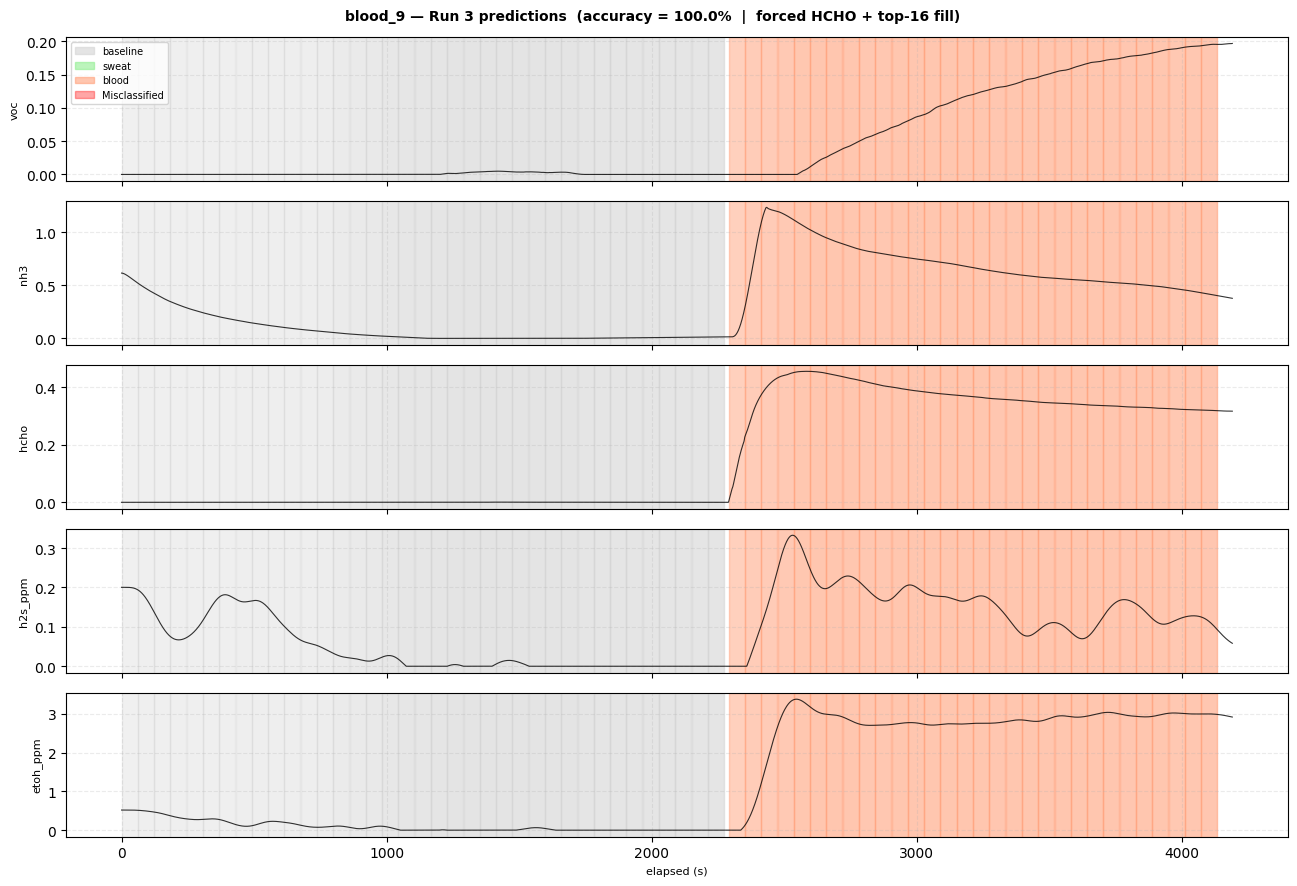

  SWEAT_7 — Run 3  (accuracy = 100.0%)
    #   t_start   t_end        True   Predicted    Conf  base / sweat / blood
  ------------------------------------------------------------------
    1        0s     60s    baseline    baseline  72.5%  0.72 / 0.26 / 0.01
    2       61s    123s    baseline    baseline  59.5%  0.59 / 0.40 / 0.01
    3      124s    185s    baseline    baseline  59.0%  0.59 / 0.39 / 0.03
    4      186s    247s    baseline    baseline  58.5%  0.58 / 0.39 / 0.03
    5      248s    308s    baseline    baseline  63.0%  0.63 / 0.35 / 0.01
    6      309s    370s    baseline    baseline  69.5%  0.69 / 0.28 / 0.03
    7      371s    432s    baseline    baseline  80.5%  0.81 / 0.17 / 0.03
    8      433s    495s    baseline    baseline  81.0%  0.81 / 0.17 / 0.03
    9      496s    558s    baseline    baseline  80.0%  0.80 / 0.17 / 0.03
   10      559s    622s    baseline    baseline  80.0%  0.80 / 0.17 / 0.03
   11      623s    684s    baseline    baseline  81.0%  0.81 / 0

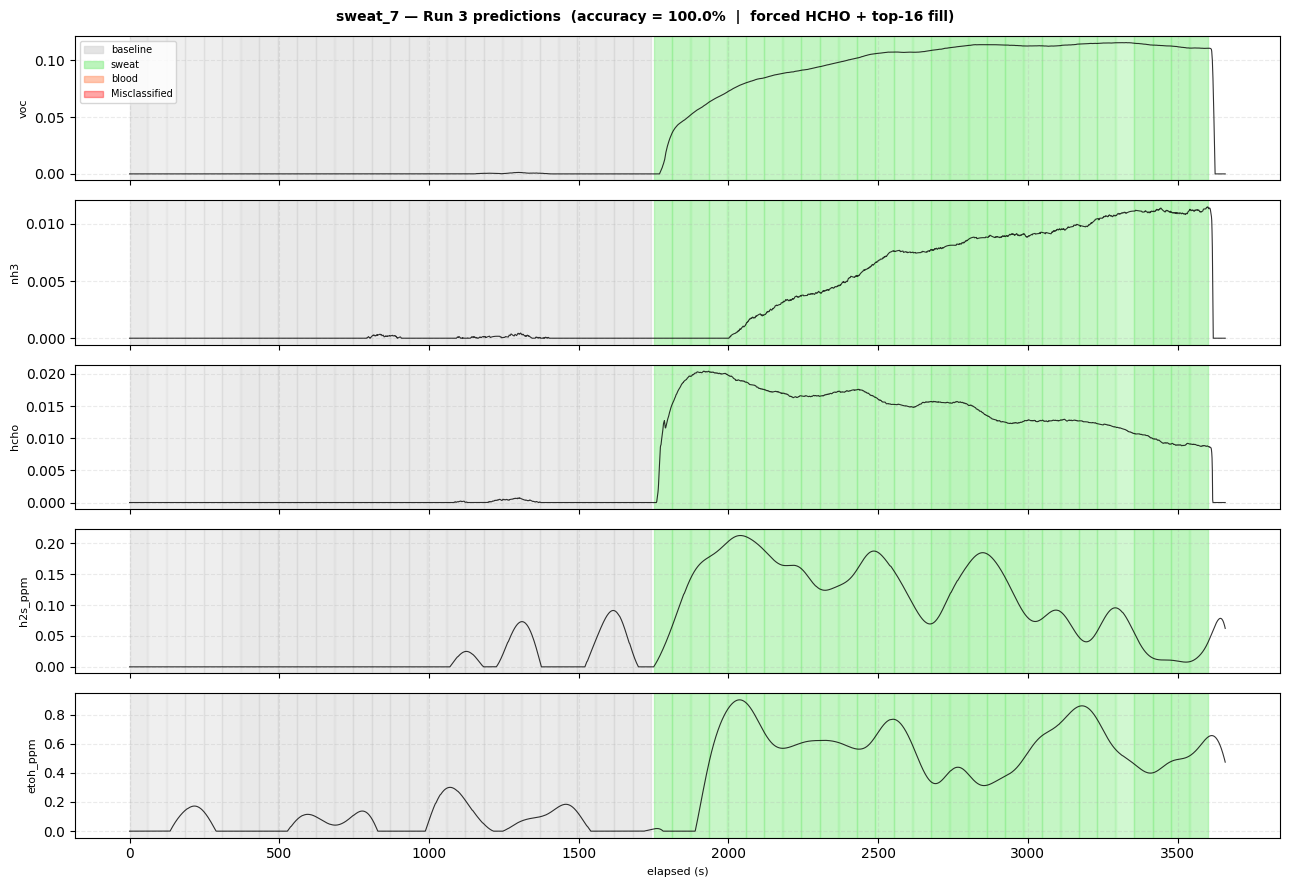

In [179]:
# ── Run 1 vs Run 2 vs Run 3 accuracy comparison ───────────────────────────────
print("─" * 80)
print("  TEST RESULTS — Run 1 vs Run 2 vs Run 3")
print("─" * 80)
print(f"  {'Session':<12}  {'Run 1 acc':>10}  {'Run 2 acc':>10}  {'Run 3 acc':>10}  {'R1→R3':>8}")
print("  " + "-" * 56)

for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    y_true = wins_s["label"].reset_index(drop=True)

    acc_r1 = accuracy_score(y_true, final_model.predict(wins_s[selected_cols]))
    acc_r2 = accuracy_score(y_true, final_model_r2.predict(wins_s[selected_cols_r2]))
    acc_r3 = accuracy_score(y_true, final_model_r3.predict(wins_s[selected_cols_r3]))

    delta = acc_r3 - acc_r1
    sign  = f"+{delta:.1%}" if delta >= 0 else f"{delta:.1%}"
    print(f"  {sess:<12}  {acc_r1:>10.1%}  {acc_r2:>10.1%}  {acc_r3:>10.1%}  {sign:>8}")

# ── Per-window breakdown and signal plots ─────────────────────────────────────
for sess in sorted(test_windows_df["session"].unique()):
    mask   = (test_windows_df["session"] == sess).values
    wins_s = test_windows_df[mask].reset_index(drop=True)
    bounds = _window_bounds(sess)
    X_sess = wins_s[selected_cols_r3]
    y_true = wins_s["label"].reset_index(drop=True)

    preds_r3  = final_model_r3.predict(X_sess)
    probas_r3 = final_model_r3.predict_proba(X_sess)

    n_correct = (preds_r3 == y_true.values).sum()
    n_total   = len(preds_r3)
    acc       = n_correct / n_total

    print("=" * 70)
    print(f"  {sess.upper()} — Run 3  (accuracy = {acc:.1%})")
    print("=" * 70)
    print(f"  {'#':>3}  {'t_start':>8}  {'t_end':>6}  {'True':>10}  {'Predicted':>10}  {'Conf':>6}  base / sweat / blood")
    print("  " + "-" * 66)
    for i in range(len(wins_s)):
        t0   = bounds.loc[i, "t_start"]
        t1   = bounds.loc[i, "t_end"]
        true = CLASS_NAMES[y_true.iloc[i]]
        pred = CLASS_NAMES[preds_r3[i]]
        conf = probas_r3[i].max()
        p    = probas_r3[i]
        mark = "  ✗" if preds_r3[i] != y_true.iloc[i] else ""
        print(f"  {i+1:>3}  {t0:>7.0f}s  {t1:>5.0f}s  {true:>10}  {pred:>10}  {conf:>5.1%}  "
              f"{p[0]:.2f} / {p[1]:.2f} / {p[2]:.2f}{mark}")

    print("\n  Prediction breakdown:")
    for lbl, name in CLASS_NAMES.items():
        count = (preds_r3 == lbl).sum()
        pct   = count / n_total
        bar   = "█" * int(pct * 30)
        print(f"    {name:<10}  {pct:>5.1%}  {bar}  ({count} windows)")

    df_sess = test_datasets_fe[sess]
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(13, 9), sharex=True)
    fill_n = N_FEATURES_R2 - len(FORCE_COLS_R3)
    fig.suptitle(f"{sess} — Run 3 predictions  (accuracy = {acc:.1%}  |  forced HCHO + top-{fill_n} fill)",
                 fontsize=10, fontweight="bold")
    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df_sess["elapsed_s"], df_sess[col], color="black", linewidth=0.8, alpha=0.8)
        for i in range(len(bounds)):
            t0   = bounds.loc[i, "t_start"]
            t1   = bounds.loc[i, "t_end"]
            pred = preds_r3[i]
            conf = probas_r3[i].max()
            true = bounds.loc[i, "label"]
            ax.axvspan(t0, t1, alpha=conf * 0.6, color=PRED_COLORS[pred])
            if pred != true:
                ax.axvspan(t0, t1, alpha=0.35, color="red")
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    patches = [mpatches.Patch(color=c, label=CLASS_NAMES[lbl], alpha=0.6)
               for lbl, c in PRED_COLORS.items()]
    patches.append(mpatches.Patch(color="red", alpha=0.35, label="Misclassified"))
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")
    plt.tight_layout()
    plt.show()
